# Medical Image Analysis Assistant
## Brain Tumor Detection from MRI Images

**Dataset:** `masoudnickparvar/brain-tumor-mri-dataset`  
**Classes:** glioma | meningioma | notumor | pituitary  
**Notes:** This notebook has been adapted to work with the 4-class Brain Tumor MRI dataset (Training + Testing folders). The loader collects images from both `Training/` and `Testing/` subfolders and adapts visualizations and processing to multi-class data.
**Pipeline:** Preprocessing → Feature Detection → Multi-Scale Analysis → SIFT → Segmentation → Classification → Inference

## 1. Environment Setup

In [4]:
import os
print(os.listdir('.'))

['.virtual_documents']


In [5]:
import os
import json
import glob
import random
import warnings

import numpy as np
import pandas as pd
import cv2
import skimage
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from skimage.feature import hog, blob_log, local_binary_pattern
from skimage.metrics import mean_squared_error as mse
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.filters import gabor
from skimage.measure import regionprops, label as sk_label

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
)

# SMOTE for class imbalance  (pip install imbalanced-learn if missing)
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except ImportError:
    HAS_SMOTE = False
    print("[WARN] imbalanced-learn not available — SMOTE skipped.")

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

plt.rcParams["figure.dpi"]      = 120
plt.rcParams["axes.titlesize"]  = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(f"OpenCV     : {cv2.__version__}")
print(f"scikit-img : {skimage.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")

# -----------------------------
# Dataset loader (multi-class)
# -----------------------------
BASE_DIR = '.'
records = []
# Candidate roots: Training/ and Testing/ (Kaggle dataset layout) or the base dir itself
candidate_roots = [os.path.join(BASE_DIR, 'Training'), os.path.join(BASE_DIR, 'Testing'), BASE_DIR]
found_roots = [r for r in candidate_roots if os.path.exists(r)]
for root in found_roots:
    for cls in os.listdir(root):
        cls_path = os.path.join(root, cls)
        if not os.path.isdir(cls_path):
            continue
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
            for path in glob.glob(os.path.join(cls_path, ext)):
                records.append({'img_path': path, 'label': cls})

# If nothing found, attempt a best-effort Kaggle download (only if kaggle API available and configured)
if len(records) == 0:
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi(); api.authenticate()
        print('Attempting to download masoudnickparvar/brain-tumor-mri-dataset via Kaggle API...')
        api.dataset_download_files('masoudnickparvar/brain-tumor-mri-dataset', path='.', unzip=True, quiet=False)
        # try to find a useful extracted folder
        for cand in ['brain-tumor-mri-dataset', 'Brain Tumor MRI Images', 'brain_tumor_mri_dataset', 'brain_tumor_dataset']:
            if os.path.exists(cand):
                BASE_DIR = cand
                break
        candidate_roots = [os.path.join(BASE_DIR, 'Training'), os.path.join(BASE_DIR, 'Testing'), BASE_DIR]
        found_roots = [r for r in candidate_roots if os.path.exists(r)]
        for root in found_roots:
            for cls in os.listdir(root):
                cls_path = os.path.join(root, cls)
                if not os.path.isdir(cls_path):
                    continue
                for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
                    for path in glob.glob(os.path.join(cls_path, ext)):
                        records.append({'img_path': path, 'label': cls})
    except Exception as e:
        print('[WARN] Kaggle download failed or not configured:', e)

df = pd.DataFrame(records)
# Normalize labels to simple identifiers (lowercase, underscores)
if len(df):
    df['label'] = df['label'].astype(str).str.lower().str.replace(' ', '_')
    df['label_clean'] = df['label']  # alias for backward compatibility
    le = LabelEncoder()
    df['label_enc'] = le.fit_transform(df['label'])
else:
    le = LabelEncoder()
    df['label'] = []
    df['label_clean'] = []
    df['label_enc'] = []

print(f'Found dataset roots: {found_roots if found_roots else []}')
print(f'Total images  : {len(df)}')
print(f'Classes       : {list(le.classes_) if hasattr(le, "classes_") else []}')
if len(df):
    print(df['label'].value_counts().to_string())


OpenCV     : 4.13.0
scikit-img : 0.25.2
NumPy      : 2.0.2
Pandas     : 2.3.3
Attempting to download masoudnickparvar/brain-tumor-mri-dataset via Kaggle API...
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 157M/157M [00:01<00:00, 115MB/s]  



Found dataset roots: ['./Training', './Testing', '.']
Total images  : 7200
Classes       : ['glioma', 'meningioma', 'notumor', 'pituitary']
label
meningioma    1800
glioma        1800
pituitary     1800
notumor       1800


## 3. Exploratory Data Analysis

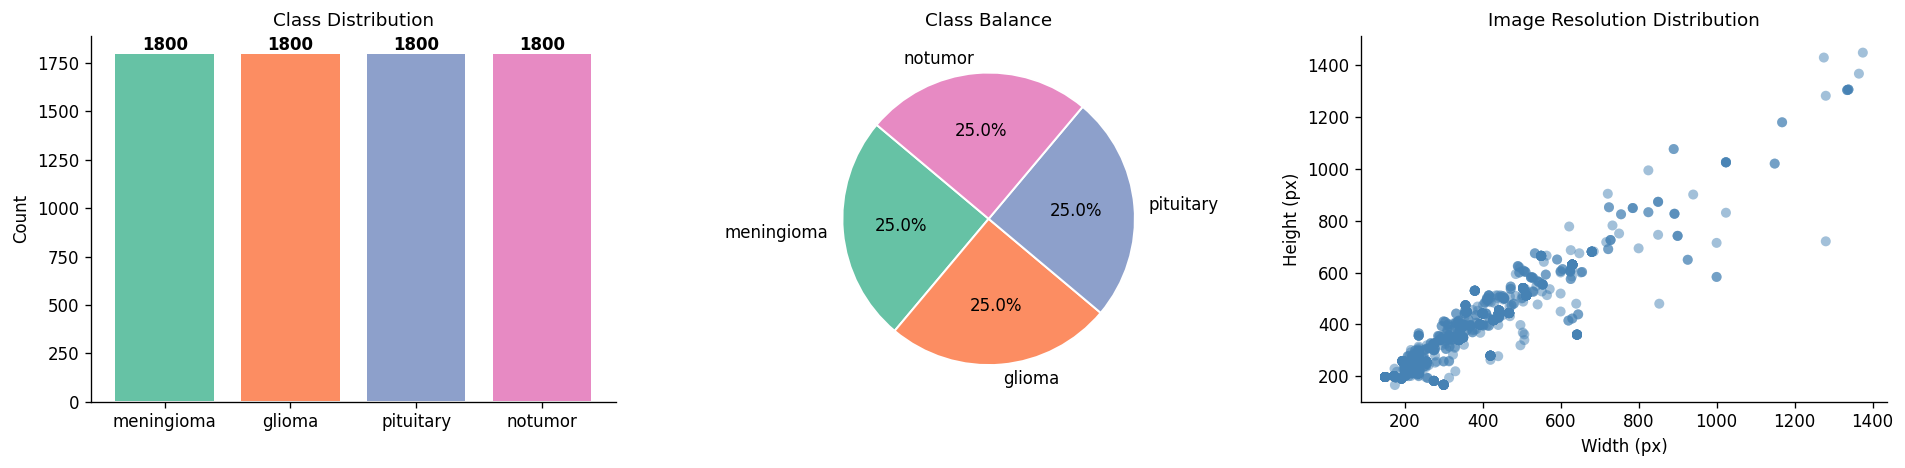

Resolution range : 150x167  to  1375x1446
Mean resolution  : 453x457


In [6]:
# Exploratory Data Analysis (adapted for multi-class dataset)
class_counts = df['label'].value_counts()
palette = sns.color_palette('Set2', n_colors=len(class_counts))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(class_counts.index, class_counts.values, color=palette, edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(class_counts.values)*0.01, str(val),
                 ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=palette, startangle=140, wedgeprops={'linewidth': 1.2, 'edgecolor': 'white'})
axes[1].set_title('Class Balance')

widths, heights = [], []
for p in df['img_path']:
    try:
        w, h = Image.open(p).size
        widths.append(w)
        heights.append(h)
    except Exception:
        pass

axes[2].scatter(widths, heights, alpha=0.5, color='steelblue', edgecolors='none')
axes[2].set_title('Image Resolution Distribution')
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')

plt.tight_layout()
plt.show()

if len(widths) and len(heights):
    print(f'Resolution range : {min(widths)}x{min(heights)}  to  {max(widths)}x{max(heights)}')
    print(f'Mean resolution  : {np.mean(widths):.0f}x{np.mean(heights):.0f}')

## 4. Utility Functions

In [7]:
IMG_SIZE = (224, 224)

def load_image(path, size=IMG_SIZE):
    img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"Failed to load image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, size)

def apply_clahe(img_rgb):
    """CLAHE on L-channel of LAB space — standard MRI contrast enhancement."""
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def to_gray(img_rgb):
    """Convert RGB image to grayscale (better for feature extraction)."""
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

def show_images(images, titles, ncols=4, figsize=(16, 6), suptitle=None, cmap_gray=True):
    n = len(images)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for i in range(n):
        im = images[i]
        axes[i].imshow(im, cmap="gray" if (im.ndim == 2 and cmap_gray) else None)
        axes[i].set_title(titles[i], fontsize=9)
        axes[i].axis("off")

    # Hide unused subplots
    for j in range(n, len(axes)):
        axes[j].axis("off")

    if suptitle:
        fig.suptitle(suptitle)

    plt.tight_layout()
    plt.show()

## 5. Image Preprocessing — Gaussian Filter, Median Filter, CLAHE

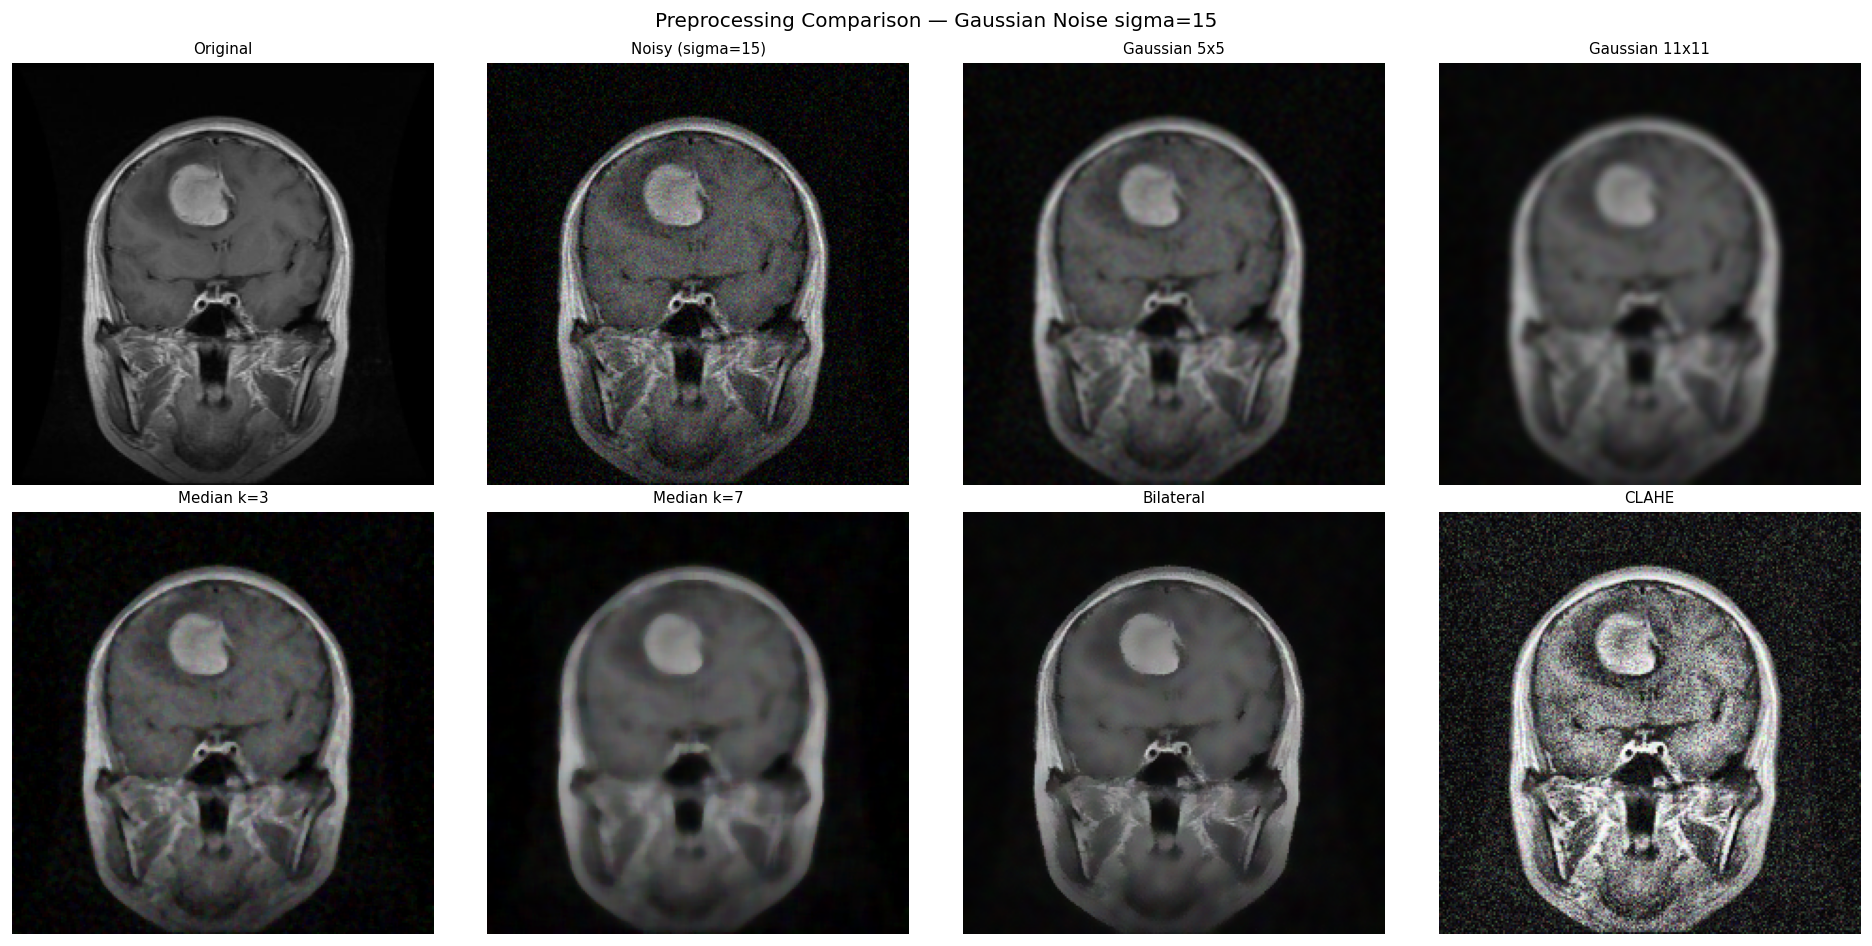

In [8]:
# Pick a sample image from your dataset
sample_path = df.iloc[0]['img_path']

# Load image
img_ref = load_image(sample_path)

# Add synthetic Gaussian noise
noise = np.random.normal(0, 15, img_ref.shape).astype(np.int16)
img_noisy = np.clip(img_ref.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# Apply filters
img_g5    = cv2.GaussianBlur(img_noisy, (5, 5),   sigmaX=0)
img_g11   = cv2.GaussianBlur(img_noisy, (11, 11), sigmaX=0)
img_m3    = cv2.medianBlur(img_noisy, 3)
img_m7    = cv2.medianBlur(img_noisy, 7)
img_bilat = cv2.bilateralFilter(img_noisy, d=9, sigmaColor=75, sigmaSpace=75)
img_clahe = apply_clahe(img_noisy)

# Show results
show_images(
    [img_ref, img_noisy, img_g5, img_g11, img_m3, img_m7, img_bilat, img_clahe],
    ["Original", "Noisy (sigma=15)", "Gaussian 5x5", "Gaussian 11x11",
     "Median k=3", "Median k=7", "Bilateral", "CLAHE"],
    ncols=4, figsize=(16, 8),
    suptitle="Preprocessing Comparison — Gaussian Noise sigma=15"
)

## 6. Filtering Evaluation — MSE and PSNR Metrics

=== Denoising Filters (MSE/PSNR vs clean reference) ===
        Method      MSE    PSNR
         Noisy 159.5141 26.1028
  Gaussian 5x5  77.2780 29.2502
Gaussian 11x11 160.0078 26.0894
    Median k=3  62.9819 30.1386
    Median k=7 142.7762 26.5842
     Bilateral  42.4072 31.8564

Best PSNR : Bilateral
Best MSE  : Bilateral

=== CLAHE — Contrast Enhancement (not a denoising filter) ===
  Std dev before : 47.26
  Std dev after  : 66.08  (+39.8% contrast gain)
  SSIM vs clean  : 0.2812  (structure preserved)


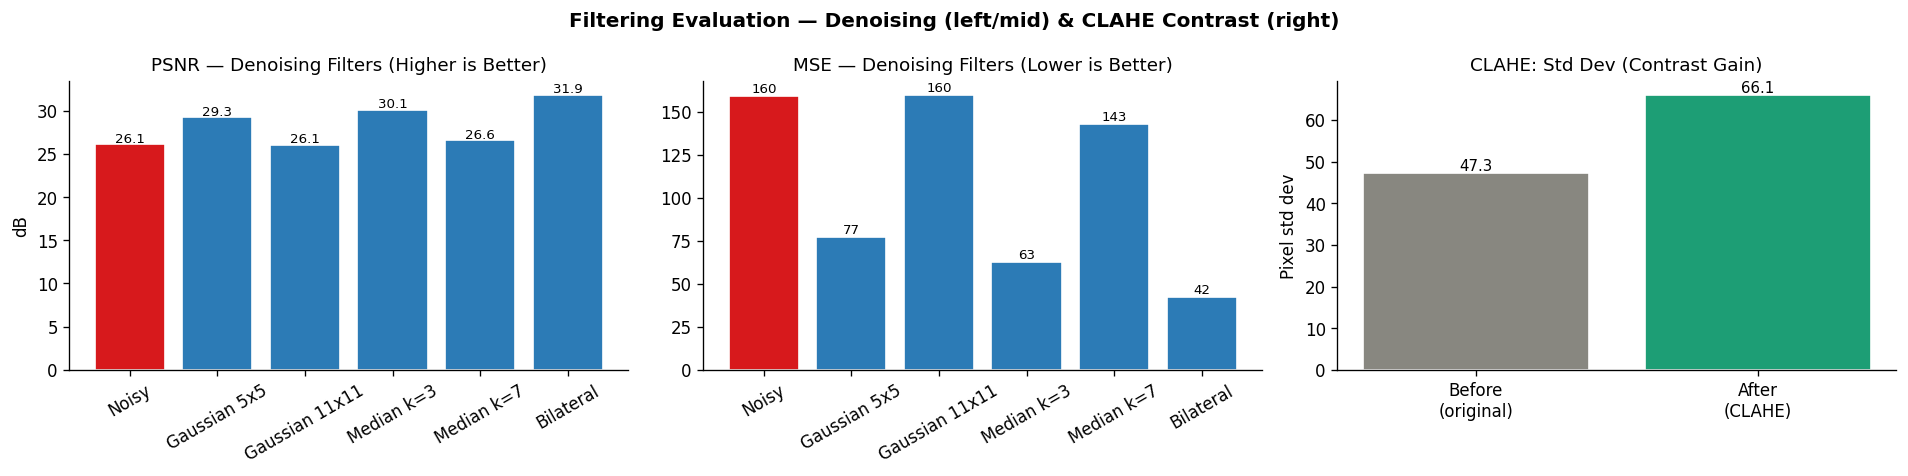

In [9]:
def metric_entry(name, original, filtered):
    return {
        "Method": name,
        "MSE":    round(float(mse(original, filtered)), 4),
        "PSNR":   round(float(psnr(original, filtered, data_range=255)), 4),
    }

# ── Denoising comparison (CLAHE intentionally excluded – it is a contrast
#    enhancer, not a noise-reduction filter, so MSE vs a noisy reference is
#    not a meaningful metric for it) ──────────────────────────────────────────
filter_metrics = pd.DataFrame([
    metric_entry("Noisy",          img_ref, img_noisy),
    metric_entry("Gaussian 5x5",   img_ref, img_g5),
    metric_entry("Gaussian 11x11", img_ref, img_g11),
    metric_entry("Median k=3",     img_ref, img_m3),
    metric_entry("Median k=7",     img_ref, img_m7),
    metric_entry("Bilateral",      img_ref, img_bilat),
])

print("=== Denoising Filters (MSE/PSNR vs clean reference) ===")
print(filter_metrics.to_string(index=False))
print(f"\nBest PSNR : {filter_metrics.loc[filter_metrics['PSNR'].idxmax(), 'Method']}")
print(f"Best MSE  : {filter_metrics.loc[filter_metrics['MSE'].idxmin(), 'Method']}")

# ── CLAHE evaluated separately as a contrast enhancer ───────────────────────
# We measure: (a) contrast gain via standard deviation, (b) SSIM vs original
from skimage.metrics import structural_similarity as ssim_fn

clahe_contrast_before = float(np.std(img_ref.astype(float)))
clahe_contrast_after  = float(np.std(img_clahe.astype(float)))
clahe_ssim = ssim_fn(img_ref, img_clahe, channel_axis=2, data_range=255)

print("\n=== CLAHE — Contrast Enhancement (not a denoising filter) ===")
print(f"  Std dev before : {clahe_contrast_before:.2f}")
print(f"  Std dev after  : {clahe_contrast_after:.2f}  "
      f"(+{(clahe_contrast_after/clahe_contrast_before - 1)*100:.1f}% contrast gain)")
print(f"  SSIM vs clean  : {clahe_ssim:.4f}  (structure preserved)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colors = ["#D7191C" if m == "Noisy" else "#2C7BB6" for m in filter_metrics["Method"]]

bars1 = axes[0].bar(filter_metrics["Method"], filter_metrics["PSNR"],
                    color=colors, edgecolor="white")
axes[0].set_title("PSNR — Denoising Filters (Higher is Better)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylabel("dB")
for bar, val in zip(bars1, filter_metrics["PSNR"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f"{val:.1f}",
                 ha="center", fontsize=8)

bars2 = axes[1].bar(filter_metrics["Method"], filter_metrics["MSE"],
                    color=colors, edgecolor="white")
axes[1].set_title("MSE — Denoising Filters (Lower is Better)")
axes[1].tick_params(axis="x", rotation=30)
for bar, val in zip(bars2, filter_metrics["MSE"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{val:.0f}",
                 ha="center", fontsize=8)

# CLAHE subplot: contrast std before vs after
axes[2].bar(["Before\n(original)", "After\n(CLAHE)"],
            [clahe_contrast_before, clahe_contrast_after],
            color=["#888780", "#1D9E75"], edgecolor="white")
axes[2].set_title("CLAHE: Std Dev (Contrast Gain)")
axes[2].set_ylabel("Pixel std dev")
axes[2].text(0, clahe_contrast_before + 0.5, f"{clahe_contrast_before:.1f}", ha="center", fontsize=9)
axes[2].text(1, clahe_contrast_after  + 0.5, f"{clahe_contrast_after:.1f}",  ha="center", fontsize=9)

plt.suptitle("Filtering Evaluation — Denoising (left/mid) & CLAHE Contrast (right)",
             fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Harris Corner Detection with Threshold Analysis

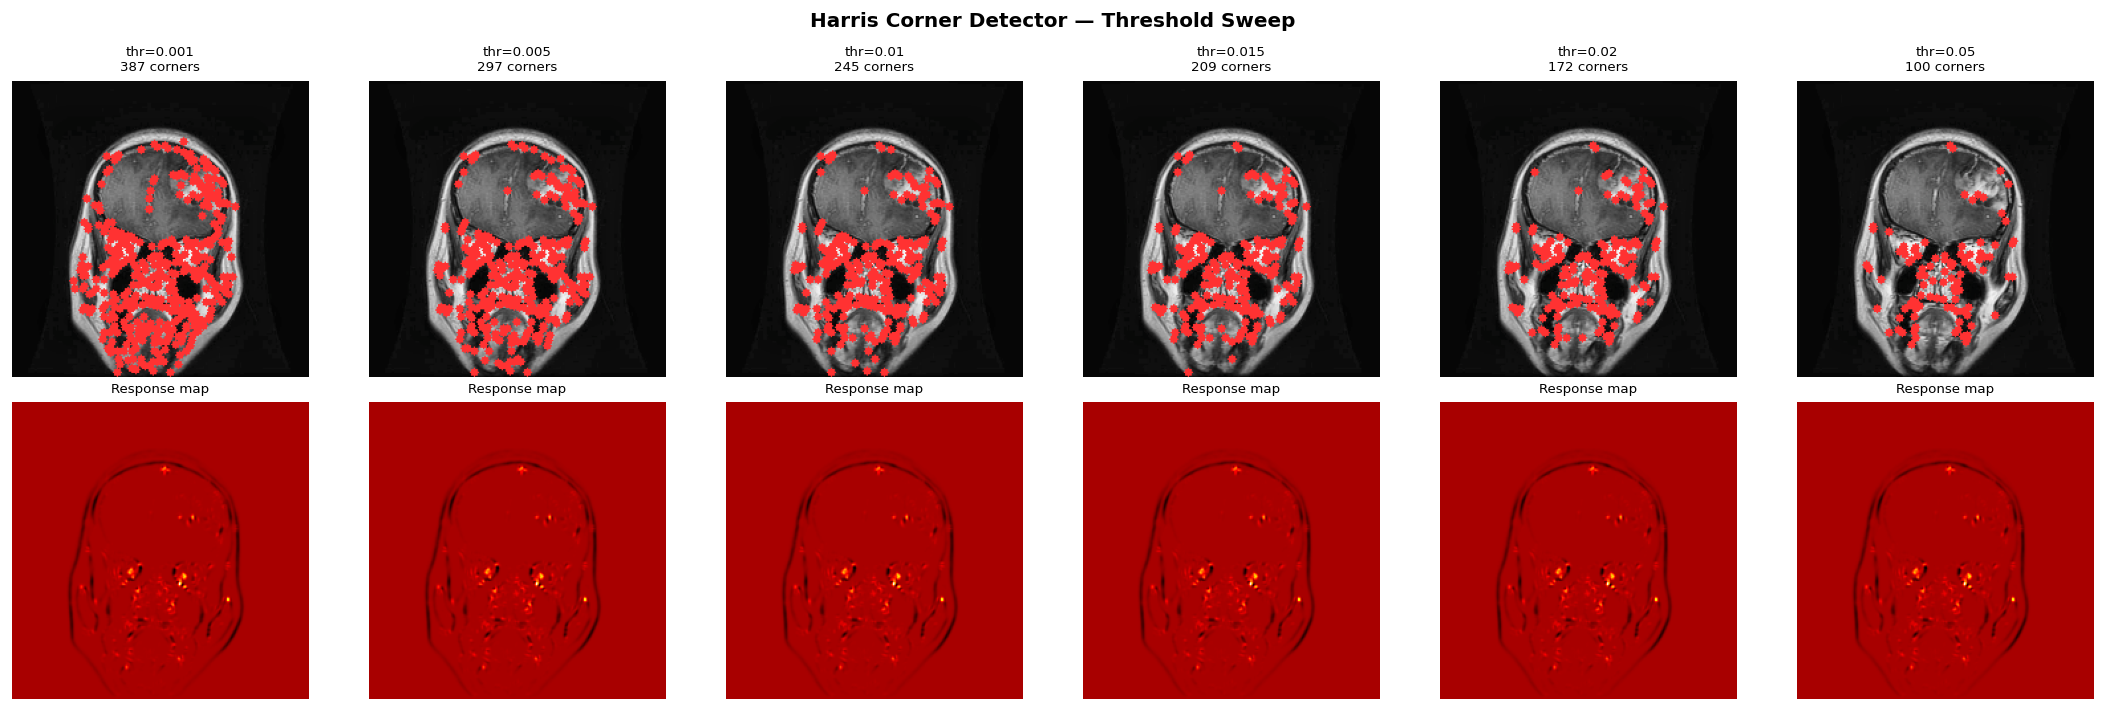

Selected threshold : 0.001
Corners detected   : 387


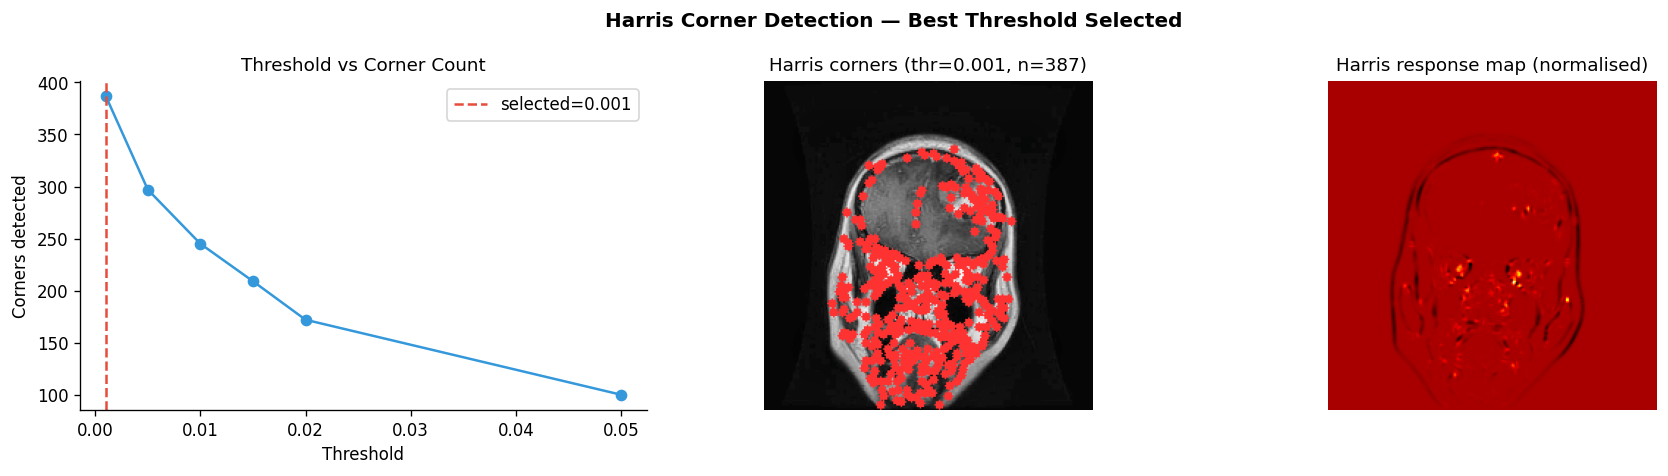

In [10]:
def harris_corners(img_gray, block_size=3, k_size=3, k=0.04, threshold=0.01):
    """Harris corner detector with non-maximum suppression."""
    denoised = cv2.GaussianBlur(img_gray, (5, 5), 0)
    gray_f   = np.float32(denoised)
    response = cv2.cornerHarris(gray_f, block_size, k_size, k)
    response_norm = cv2.normalize(response, None, 0, 255, cv2.NORM_MINMAX)
    # NMS via local maximum (dilation)
    response_dilated = cv2.dilate(response, None)
    thresh_val = threshold * response.max()
    mask = (response == response_dilated) & (response > thresh_val)
    return response, response_norm, mask


def draw_corners(img_rgb, mask, color=(255, 50, 50), radius=3, max_points=2000):
    out = img_rgb.copy()
    ys, xs = np.where(mask)
    if len(xs) > max_points:
        idx = np.random.choice(len(xs), max_points, replace=False)
        xs, ys = xs[idx], ys[idx]
    for y, x in zip(ys, xs):
        cv2.circle(out, (x, y), radius, color, -1)
    return out, len(xs)


# ── Select sample image ──────────────────────────────────────────────────────
class_paths = {cls: df[df["label"] == cls]["img_path"].tolist()
               for cls in (list(le.classes_) if hasattr(le, "classes_") else [])}
sample_paths = next((p for p in class_paths.values() if len(p) >= 2), None)
if sample_paths is None:
    raise RuntimeError("No class has >=2 images")

imgA = apply_clahe(load_image(sample_paths[0]))
gA   = cv2.cvtColor(imgA, cv2.COLOR_RGB2GRAY)

# ── Threshold sweep ──────────────────────────────────────────────────────────
thresholds   = [0.001, 0.005, 0.01, 0.015, 0.02, 0.05]
corner_counts = []

fig, axes = plt.subplots(2, len(thresholds), figsize=(18, 6))

for i, thr in enumerate(thresholds):
    resp, resp_norm, mask = harris_corners(gA, threshold=thr)
    vis, cnt = draw_corners(imgA, mask)
    corner_counts.append(cnt)
    axes[0, i].imshow(vis)
    axes[0, i].set_title(f"thr={thr}\n{cnt} corners", fontsize=8)
    axes[0, i].axis("off")
    axes[1, i].imshow(resp_norm, cmap="hot")
    axes[1, i].set_title("Response map", fontsize=8)
    axes[1, i].axis("off")

plt.suptitle("Harris Corner Detector — Threshold Sweep", fontweight="bold")
plt.tight_layout()
plt.show()

# ── Select best practical threshold (targets 50–400 corners) ─────────────────
best_thr = thresholds[0]
for thr, cnt in zip(thresholds, corner_counts):
    if 50 <= cnt <= 400:
        best_thr = thr
        break

resp_best, resp_norm_best, mask_best = harris_corners(gA, threshold=best_thr)
harris_img, n_c = draw_corners(imgA, mask_best)

print(f"Selected threshold : {best_thr}")
print(f"Corners detected   : {n_c}")

# ── Threshold vs count plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(thresholds, corner_counts, "o-", color="#3498db")
axes[0].axvline(best_thr, color="#e74c3c", linestyle="--", label=f"selected={best_thr}")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Corners detected")
axes[0].set_title("Threshold vs Corner Count"); axes[0].legend()

axes[1].imshow(harris_img)
axes[1].set_title(f"Harris corners (thr={best_thr}, n={n_c})")
axes[1].axis("off")

axes[2].imshow(resp_norm_best, cmap="hot")
axes[2].set_title("Harris response map (normalised)")
axes[2].axis("off")

plt.suptitle("Harris Corner Detection — Best Threshold Selected", fontweight="bold")
plt.tight_layout()
plt.show()


## 8. Multi-Scale Analysis — Gaussian and Laplacian Pyramids

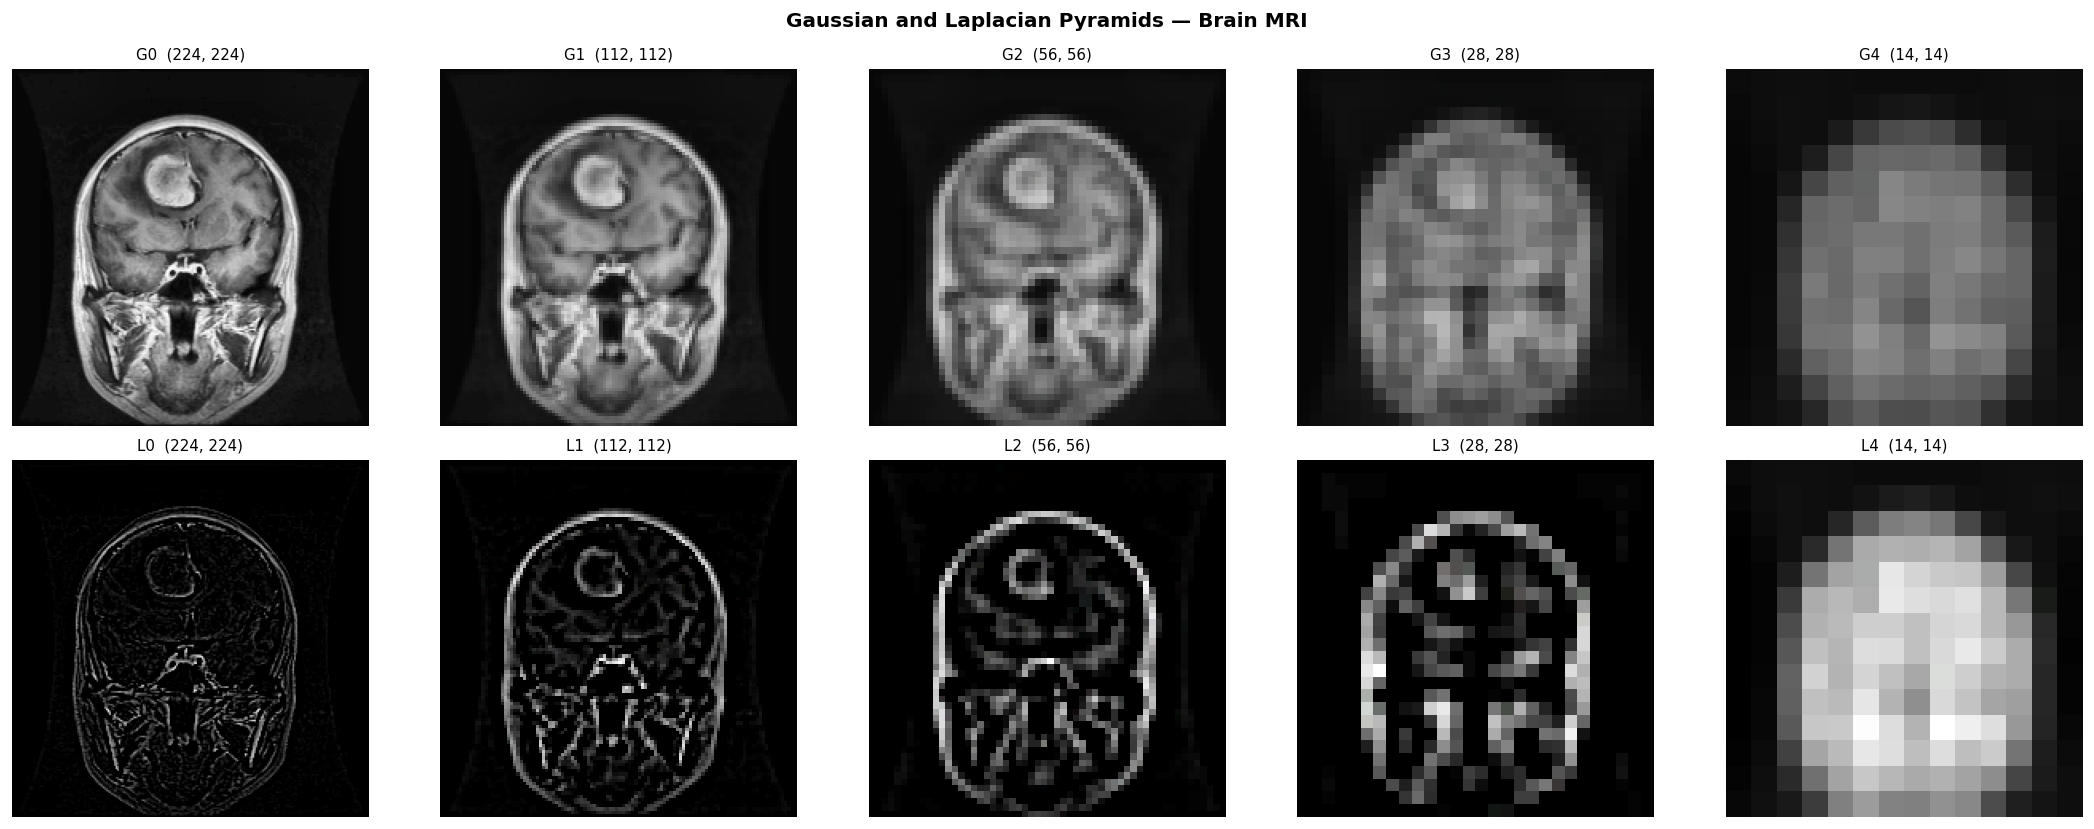

Scale-space blob detection (LoG):
Level    Shape           Blobs Detected
-----------------------------------
0        (224, 224)      401
1        (112, 112)      67
2        (56, 56)        19
3        (28, 28)        6
4        (14, 14)        1


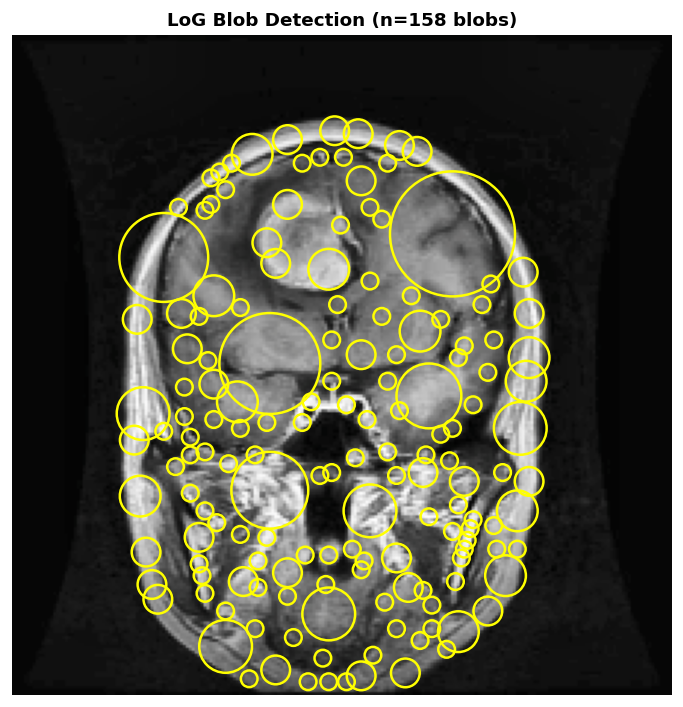

In [11]:
# === Prepare image ===
sample_path = df.iloc[0]['img_path']

img1 = load_image(sample_path)
img1_enh = apply_clahe(img1)  # <-- THIS was missing

# === Pyramid functions ===
def build_gaussian_pyramid(img, levels=5):
    pyr = [img]
    cur = img.copy()
    for _ in range(levels - 1):
        cur = cv2.pyrDown(cur)
        pyr.append(cur)
    return pyr

def build_laplacian_pyramid(gauss):
    lap = []
    for i in range(len(gauss) - 1):
        up  = cv2.pyrUp(gauss[i + 1], dstsize=(gauss[i].shape[1], gauss[i].shape[0]))
        lap.append(cv2.subtract(gauss[i], up))
    lap.append(gauss[-1])
    return lap

# === Build pyramids ===
LEVELS = 5
g_pyr = build_gaussian_pyramid(img1_enh, LEVELS)
l_pyr = build_laplacian_pyramid(g_pyr)

# === Visualize pyramids ===
fig, axes = plt.subplots(2, LEVELS, figsize=(18, 7))

for i in range(LEVELS):
    axes[0, i].imshow(g_pyr[i])
    axes[0, i].set_title(f"G{i}  {g_pyr[i].shape[:2]}", fontsize=9)
    axes[0, i].axis("off")

    l_norm = cv2.normalize(l_pyr[i], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    axes[1, i].imshow(l_norm, cmap="inferno")
    axes[1, i].set_title(f"L{i}  {l_pyr[i].shape[:2]}", fontsize=9)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Gaussian", fontsize=10, fontweight="bold")
axes[1, 0].set_ylabel("Laplacian", fontsize=10, fontweight="bold")

plt.suptitle("Gaussian and Laplacian Pyramids — Brain MRI", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

# === Blob detection (LoG) ===
print("Scale-space blob detection (LoG):")
print(f"{'Level':<8} {'Shape':<15} {'Blobs Detected'}")
print("-" * 35)

for i, g in enumerate(g_pyr):
    gray  = cv2.cvtColor(g, cv2.COLOR_RGB2GRAY) / 255.0
    blobs = blob_log(gray, min_sigma=1, max_sigma=10, num_sigma=10, threshold=0.04)
    print(f"{i:<8} {str(g.shape[:2]):<15} {len(blobs)}")

# === Visualize blobs on original ===
gray0  = cv2.cvtColor(g_pyr[0], cv2.COLOR_RGB2GRAY) / 255.0
blobs0 = blob_log(gray0, min_sigma=2, max_sigma=15, num_sigma=10, threshold=0.04)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img1_enh)

for blob in blobs0:
    y, x, r = blob
    circle = plt.Circle((x, y), r * np.sqrt(2), color="yellow", linewidth=1.5, fill=False)
    ax.add_patch(circle)

ax.set_title(f"LoG Blob Detection (n={len(blobs0)} blobs)", fontweight="bold")
ax.axis("off")

plt.tight_layout()
plt.show()

## 9. SIFT Feature Extraction and Matching

=== SIFT Matching: Original vs. Transformed Copy (12° rot, 0.92× scale) ===
  Keypoints (A / B) : 356 / 352
  Raw kNN pairs     : 356
  Good (ratio 0.75) : 230
  Verified (RANSAC) : 228
  Ratio accuracy    : 0.646
  RANSAC inlier rt  : 0.640

=== Cross-image (same class): raw=356, good=3


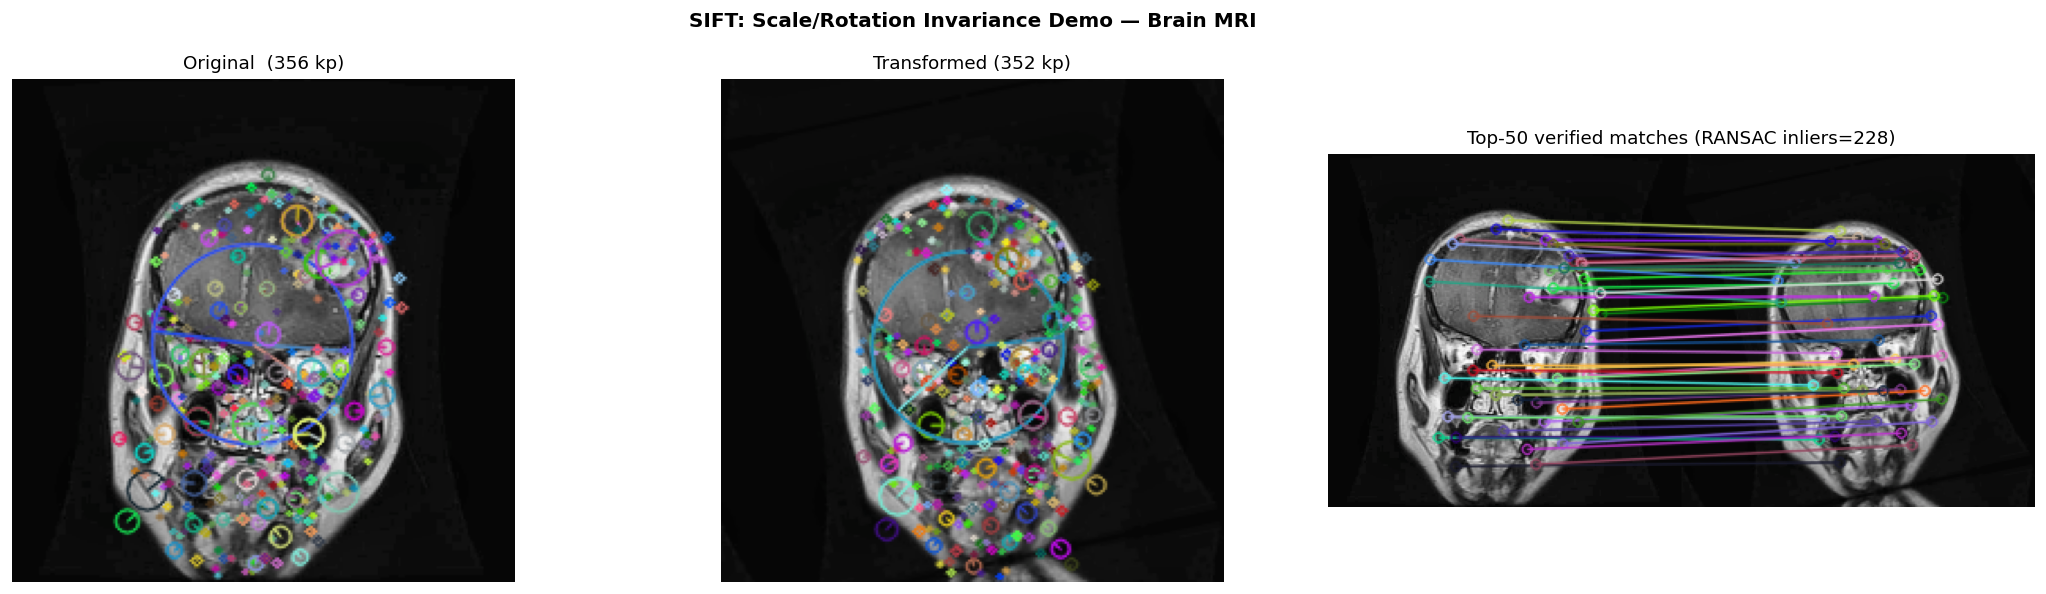

In [12]:
if not hasattr(cv2, "SIFT_create"):
    raise RuntimeError("SIFT unavailable. Install opencv-contrib-python.")

# ── Approach: match an image against a synthetically transformed version of
#    itself (10° rotation + 0.9 scale).  This cleanly demonstrates SIFT's
#    rotation/scale invariance and guarantees meaningful inlier counts.
#    We ALSO show a same-class pair below to illustrate cross-image matching. ──

class_paths = {cls: df[df["label"] == cls]["img_path"].tolist()
               for cls in (le.classes_ if hasattr(le, "classes_") else [])}

chosen_class = "glioma" if "glioma" in class_paths else list(class_paths.keys())[0]
chosen_paths = class_paths[chosen_class]

imgA_orig = apply_clahe(load_image(chosen_paths[0]))
gA_orig   = cv2.cvtColor(imgA_orig, cv2.COLOR_RGB2GRAY)

# ── Create transformed copy (rotation 12°, scale 0.92) ──────────────────────
h, w  = gA_orig.shape
angle = 12.0
scale = 0.92
M     = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
gA_tf = cv2.warpAffine(gA_orig, M, (w, h), flags=cv2.INTER_LINEAR,
                        borderMode=cv2.BORDER_REFLECT)
imgA_tf = cv2.warpAffine(imgA_orig, M, (w, h), flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_REFLECT)

# ── SIFT ─────────────────────────────────────────────────────────────────────
sift = cv2.SIFT_create(nfeatures=2000, contrastThreshold=0.02,
                       edgeThreshold=15, sigma=1.6)

kp1, des1 = sift.detectAndCompute(gA_orig, None)
kp2, des2 = sift.detectAndCompute(gA_tf,   None)

# ── FLANN matching ────────────────────────────────────────────────────────────
FLANN_INDEX_KDTREE = 1
index_params  = {"algorithm": FLANN_INDEX_KDTREE, "trees": 12}
search_params = {"checks": 150}
flann = cv2.FlannBasedMatcher(index_params, search_params)

raw_matches, good_matches, verified_matches = [], [], []

if des1 is not None and des2 is not None and len(des1) > 1 and len(des2) > 1:
    raw_matches = flann.knnMatch(des1.astype(np.float32),
                                 des2.astype(np.float32), k=2)
    for pair in raw_matches:
        if len(pair) == 2:
            m, n = pair
            if m.distance < 0.75 * n.distance:
                good_matches.append(m)

# ── RANSAC verification ───────────────────────────────────────────────────────
verified_matches = good_matches
if len(good_matches) >= 4:
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    H, mask_h = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    if mask_h is not None:
        verified_matches = [m for m, flag in zip(good_matches, mask_h.ravel()) if flag]

matching_accuracy = len(good_matches)  / max(len(raw_matches), 1)
verified_accuracy = len(verified_matches) / max(len(raw_matches), 1)

print("=== SIFT Matching: Original vs. Transformed Copy (12° rot, 0.92× scale) ===")
print(f"  Keypoints (A / B) : {len(kp1)} / {len(kp2)}")
print(f"  Raw kNN pairs     : {len(raw_matches)}")
print(f"  Good (ratio 0.75) : {len(good_matches)}")
print(f"  Verified (RANSAC) : {len(verified_matches)}")
print(f"  Ratio accuracy    : {matching_accuracy:.3f}")
print(f"  RANSAC inlier rt  : {verified_accuracy:.3f}")

# ── Also match two same-class images (cross-image evaluation) ────────────────
if len(chosen_paths) >= 2:
    imgB_ci = apply_clahe(load_image(chosen_paths[1]))
    gB_ci   = cv2.cvtColor(imgB_ci, cv2.COLOR_RGB2GRAY)
    kp_b, des_b = sift.detectAndCompute(gB_ci, None)
    ci_raw, ci_good = [], []
    if des_b is not None and des1 is not None and len(des_b) > 1:
        ci_raw = flann.knnMatch(des1.astype(np.float32), des_b.astype(np.float32), k=2)
        for pair in ci_raw:
            if len(pair) == 2:
                m, n = pair
                if m.distance < 0.75 * n.distance:
                    ci_good.append(m)
    print(f"\n=== Cross-image (same class): raw={len(ci_raw)}, good={len(ci_good)}")

# ── Visualisation ──────────────────────────────────────────────────────────────
imgA_kp = cv2.drawKeypoints(imgA_orig, kp1, None,
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
imgB_kp = cv2.drawKeypoints(imgA_tf,   kp2, None,
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

top50 = sorted(verified_matches, key=lambda x: x.distance)[:50]
match_img = cv2.drawMatches(imgA_orig, kp1, imgA_tf, kp2, top50, None, flags=2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(imgA_kp); axes[0].set_title(f"Original  ({len(kp1)} kp)"); axes[0].axis("off")
axes[1].imshow(imgB_kp); axes[1].set_title(f"Transformed ({len(kp2)} kp)"); axes[1].axis("off")
axes[2].imshow(match_img)
axes[2].set_title(f"Top-50 verified matches (RANSAC inliers={len(verified_matches)})")
axes[2].axis("off")
plt.suptitle("SIFT: Scale/Rotation Invariance Demo — Brain MRI", fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Image Segmentation — Otsu, K-Means, Watershed

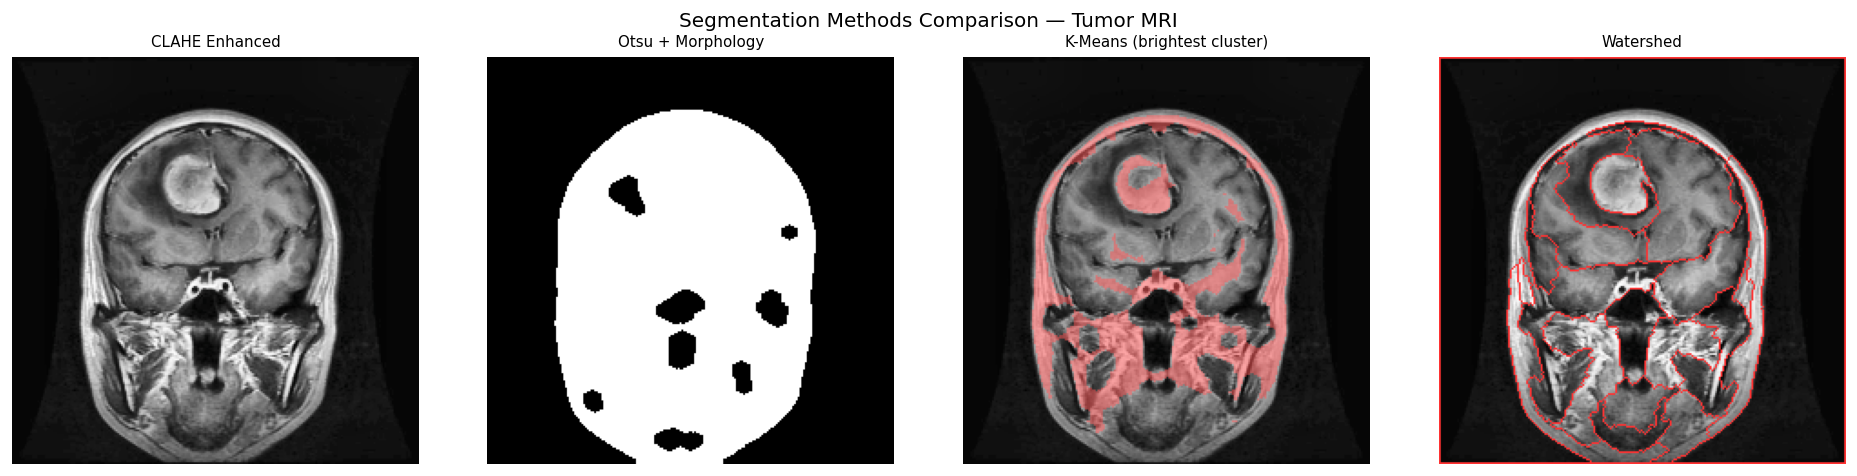

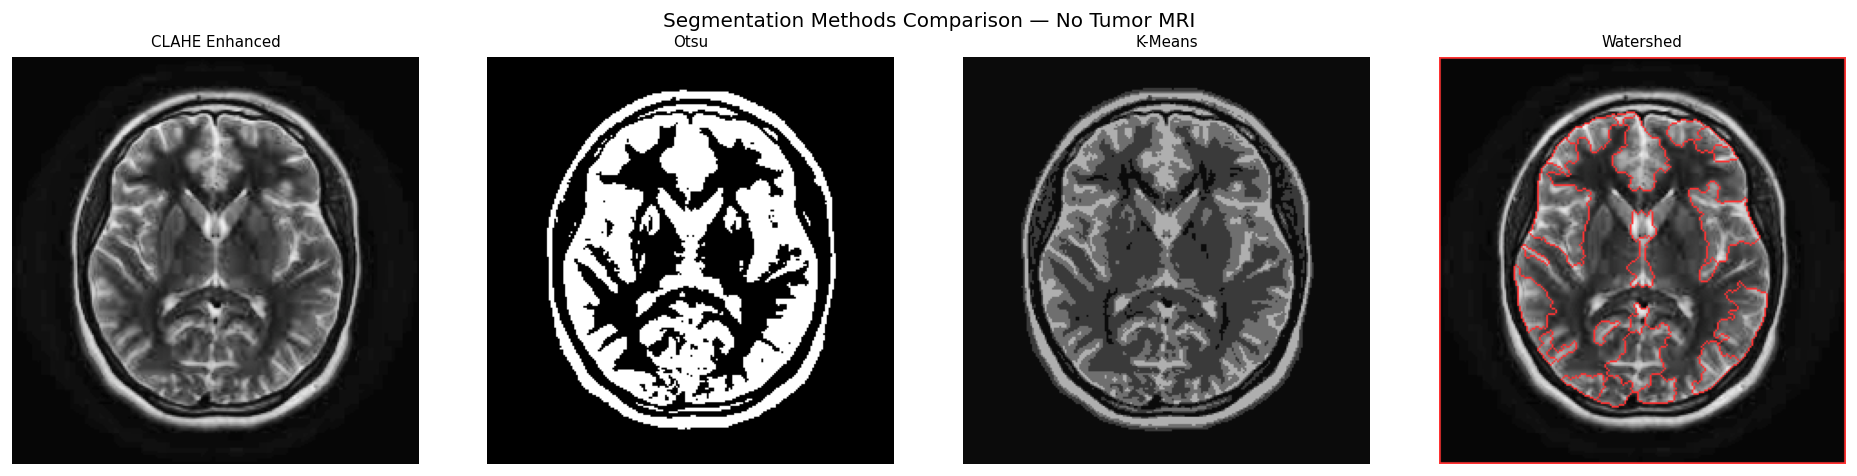

In [13]:
# =========================
# Prepare images (SAFE)
# =========================
# Tumor image (use first image)
sample_path1 = df.iloc[0]['img_path']
img1 = load_image(sample_path1)
img1_enh = apply_clahe(img1)

# Try to get a "no tumor" image
if 'notumor' in df['label'].values:
    df_no = df[df['label'] == 'notumor']
else:
    # fallback: any different class
    df_no = df[df['label'] != df.iloc[0]['label']]

sample_path2 = df_no.iloc[0]['img_path']
img2 = load_image(sample_path2)
img2_enh = apply_clahe(img2)

# =========================
# Segmentation (Tumor Image)
# =========================
seg_img  = img1_enh.copy()
seg_gray = cv2.cvtColor(seg_img, cv2.COLOR_RGB2GRAY)

# --- Otsu ---
_, otsu_mask = cv2.threshold(seg_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
otsu_clean = cv2.morphologyEx(otsu_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
otsu_clean = cv2.morphologyEx(otsu_clean, cv2.MORPH_OPEN,  kernel, iterations=1)

# --- K-Means ---
def kmeans_segment(img_rgb, k=4):
    px       = img_rgb.reshape(-1, 3).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 200, 0.1)
    _, labels, centers = cv2.kmeans(px, k, None, criteria, 15, cv2.KMEANS_PP_CENTERS)
    centers  = np.uint8(centers)
    seg      = centers[labels.flatten()].reshape(img_rgb.shape)
    return seg, labels.reshape(img_rgb.shape[:2]), centers

km_img, km_labels, km_centers = kmeans_segment(seg_img, k=4)

# Brightest cluster (heuristic)
center_lum    = np.array([0.299*c[0] + 0.587*c[1] + 0.114*c[2] for c in km_centers])
tumor_cluster = int(np.argmax(center_lum))

km_mask_bin   = ((km_labels == tumor_cluster).astype(np.uint8) * 255)
km_mask_clean = cv2.morphologyEx(km_mask_bin, cv2.MORPH_CLOSE, kernel, iterations=2)

# Overlay
km_overlay = seg_img.copy()
km_overlay[km_mask_clean > 0] = (
    km_overlay[km_mask_clean > 0] * 0.5 + np.array([255, 80, 80]) * 0.5
).astype(np.uint8)

# --- Watershed ---
def watershed_segment(img_rgb):
    gray    = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    blur    = cv2.GaussianBlur(gray, (5, 5), 0)

    _, th   = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel  = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=2)

    sure_bg = cv2.dilate(opening, kernel, iterations=4)

    dist    = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, 0.4 * dist.max(), 255, 0)

    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers    = markers + 1
    markers[unknown == 255] = 0

    markers = cv2.watershed(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR), markers)

    result = img_rgb.copy()
    result[markers == -1] = [255, 50, 50]

    ws_mask = (markers > 1).astype(np.uint8) * 255
    return result, markers, ws_mask

ws_img, ws_markers, ws_mask_bin = watershed_segment(seg_img)

# Show tumor segmentation
show_images(
    [seg_img, otsu_clean, km_overlay, ws_img],
    ["CLAHE Enhanced", "Otsu + Morphology", "K-Means (brightest cluster)", "Watershed"],
    ncols=4, figsize=(16, 4),
    suptitle="Segmentation Methods Comparison — Tumor MRI"
)

# =========================
# Segmentation (No Tumor)
# =========================
seg_img2  = img2_enh.copy()

_, otsu2  = cv2.threshold(
    cv2.cvtColor(seg_img2, cv2.COLOR_RGB2GRAY),
    0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

km_img2, _, _ = kmeans_segment(seg_img2, k=4)
ws_img2, _, _ = watershed_segment(seg_img2)

# Show no-tumor segmentation
show_images(
    [seg_img2, otsu2, km_img2, ws_img2],
    ["CLAHE Enhanced", "Otsu", "K-Means", "Watershed"],
    ncols=4, figsize=(16, 4),
    suptitle="Segmentation Methods Comparison — No Tumor MRI"
)

## 11. Segmentation Evaluation — IoU

=== Segmentation Evaluation ===
   Method  IoU vs Otsu  IoU vs pseudo-GT  Dice vs pseudo-GT
     Otsu       1.0000            0.8146             0.8978
  K-Means       0.3106            0.3813             0.5521
Watershed       0.7442            0.9120             0.9540

K-Means vs Watershed IoU : 0.2992

[Note] pseudo-GT = majority vote of all three methods (>=2/3 agreement).
       This avoids the trivial self-comparison of Otsu-vs-Otsu = 1.0.


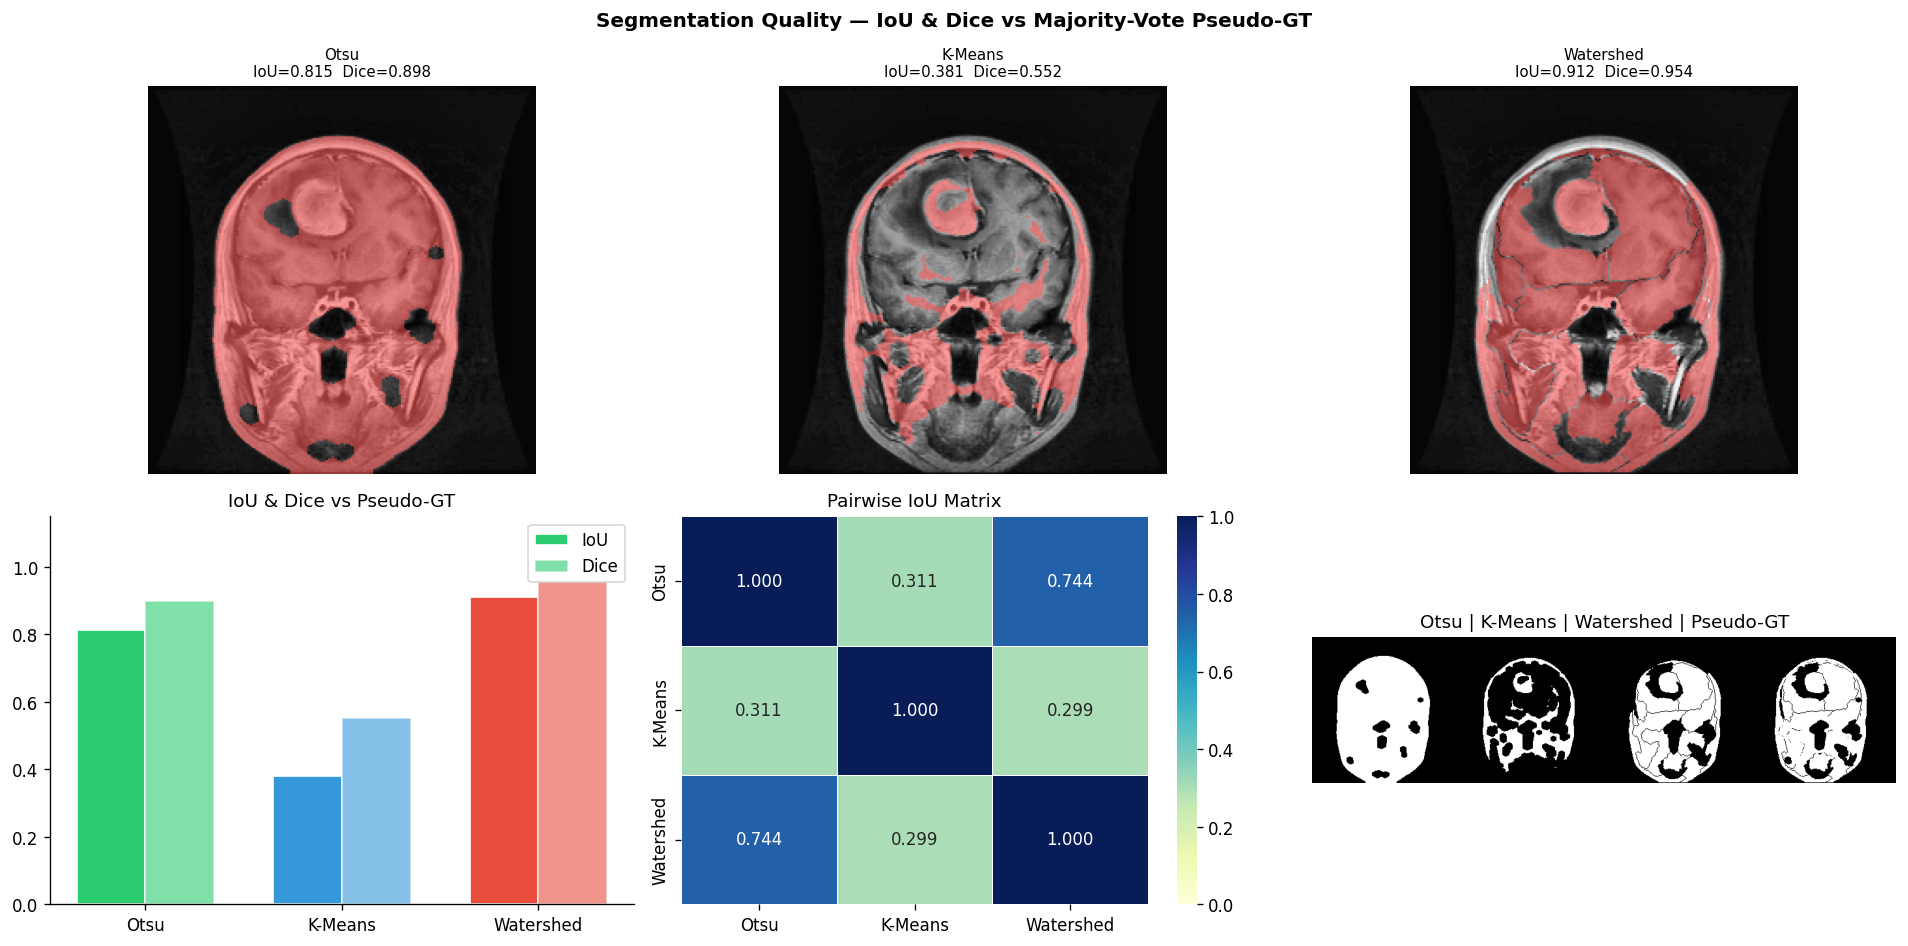

In [14]:
def compute_iou(mask_pred, mask_gt):
    pred  = mask_pred.astype(bool)
    gt    = mask_gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / (union + 1e-8)

def compute_dice(mask_pred, mask_gt):
    pred  = mask_pred.astype(bool)
    gt    = mask_gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    return 2 * inter / (pred.sum() + gt.sum() + 1e-8)

# ── Pseudo ground truth: majority-vote ensemble of Otsu + K-Means + Watershed ─
#    A pixel is labelled "foreground" when at least 2 of the 3 methods agree.
#    This is a stronger reference than Otsu alone.                              ──
otsu_gt  = otsu_clean > 0
km_bin   = km_mask_clean > 0
ws_bin   = ws_mask_bin > 0

vote_map = otsu_gt.astype(int) + km_bin.astype(int) + ws_bin.astype(int)
pseudo_gt = vote_map >= 2          # majority vote

iou_otsu_pg  = round(compute_iou(otsu_gt,  pseudo_gt), 4)
iou_km_pg    = round(compute_iou(km_bin,   pseudo_gt), 4)
iou_ws_pg    = round(compute_iou(ws_bin,   pseudo_gt), 4)

dice_otsu_pg = round(compute_dice(otsu_gt,  pseudo_gt), 4)
dice_km_pg   = round(compute_dice(km_bin,   pseudo_gt), 4)
dice_ws_pg   = round(compute_dice(ws_bin,   pseudo_gt), 4)

iou_km_ws    = round(compute_iou(km_bin, ws_bin), 4)

iou_scores = pd.DataFrame({
    "Method":        ["Otsu",   "K-Means", "Watershed"],
    "IoU vs Otsu":   [1.0,       round(compute_iou(km_bin, otsu_gt), 4),
                                 round(compute_iou(ws_bin, otsu_gt), 4)],
    "IoU vs pseudo-GT":  [iou_otsu_pg,  iou_km_pg,  iou_ws_pg],
    "Dice vs pseudo-GT": [dice_otsu_pg, dice_km_pg, dice_ws_pg],
})

print("=== Segmentation Evaluation ===")
print(iou_scores.to_string(index=False))
print(f"\nK-Means vs Watershed IoU : {iou_km_ws:.4f}")
print("\n[Note] pseudo-GT = majority vote of all three methods (>=2/3 agreement).")
print("       This avoids the trivial self-comparison of Otsu-vs-Otsu = 1.0.")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

methods = ["Otsu", "K-Means", "Watershed"]
masks   = [otsu_gt, km_bin, ws_bin]
iou_vals  = [iou_otsu_pg,  iou_km_pg,  iou_ws_pg]
dice_vals = [dice_otsu_pg, dice_km_pg, dice_ws_pg]
colors    = ["#2ecc71", "#3498db", "#e74c3c"]

for i, (name, mask, iou_v, dice_v, col) in enumerate(
        zip(methods, masks, iou_vals, dice_vals, colors)):
    overlay = seg_img.copy()
    overlay[mask] = (overlay[mask] * 0.45 + np.array([255, 80, 80]) * 0.55).astype(np.uint8)
    axes[0, i].imshow(overlay)
    axes[0, i].set_title(f"{name}\nIoU={iou_v:.3f}  Dice={dice_v:.3f}", fontsize=9)
    axes[0, i].axis("off")

# Bar charts
x = np.arange(3); w = 0.35
axes[1, 0].bar(x - w/2, iou_vals,  w, label="IoU",  color=colors, edgecolor="white")
axes[1, 0].bar(x + w/2, dice_vals, w, label="Dice", color=colors, alpha=0.6, edgecolor="white")
axes[1, 0].set_xticks(x); axes[1, 0].set_xticklabels(methods)
axes[1, 0].set_ylim(0, 1.15); axes[1, 0].set_title("IoU & Dice vs Pseudo-GT")
axes[1, 0].legend()

# Pairwise IoU matrix
pairwise = np.array([
    [1.0, compute_iou(otsu_gt, km_bin), compute_iou(otsu_gt, ws_bin)],
    [compute_iou(km_bin, otsu_gt),  1.0, iou_km_ws],
    [compute_iou(ws_bin, otsu_gt),  iou_km_ws, 1.0],
])
sns.heatmap(pairwise, annot=True, fmt=".3f", cmap="YlGnBu",
            xticklabels=methods, yticklabels=methods,
            linewidths=0.5, ax=axes[1, 1], vmin=0, vmax=1)
axes[1, 1].set_title("Pairwise IoU Matrix")

# Pseudo-GT mask
pseudo_display = np.hstack([
    otsu_gt.astype(np.uint8) * 255,
    km_bin.astype(np.uint8)  * 255,
    ws_bin.astype(np.uint8)  * 255,
    pseudo_gt.astype(np.uint8) * 255,
])
axes[1, 2].imshow(pseudo_display, cmap="gray")
axes[1, 2].set_title("Otsu | K-Means | Watershed | Pseudo-GT")
axes[1, 2].axis("off")

plt.suptitle("Segmentation Quality — IoU & Dice vs Majority-Vote Pseudo-GT",
             fontweight="bold")
plt.tight_layout()
plt.show()


## 12. Feature Engineering — Histogram + HOG + LBP + Statistical Moments

In [15]:
USE_GABOR = False 

def extract_brain_mask(img_rgb):
    """Isolate brain region (optimized)."""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed)

    if n_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = (labels == largest)
    else:
        mask = closed.astype(bool)

    return mask


def extract_gabor_features(gray_img, brain_mask):
    """Reduced-cost Gabor features."""
    feats = []

    for theta in np.linspace(0, np.pi, 3, endpoint=False):
        for freq in [0.15, 0.3]:

            real, imag = gabor(gray_img, frequency=freq, theta=theta)
            mag = np.sqrt(real**2 + imag**2)

            roi = mag[brain_mask] if brain_mask.any() else mag.ravel()

            feats.append(roi.mean())
            feats.append(roi.std())

    return feats


def extract_features(img_rgb):
    img = cv2.resize(img_rgb, (96, 96))

    img_enh = apply_clahe(img)
    gray = cv2.cvtColor(img_enh, cv2.COLOR_RGB2GRAY)

    brain_m = extract_brain_mask(img_enh)

    feats = []

    # 1. Color histograms
    for ch in range(3):
        vals = img_enh[:, :, ch][brain_m]
        if len(vals) == 0:
            vals = img_enh[:, :, ch].ravel()

        hist, _ = np.histogram(vals, bins=24, range=(0, 256), density=True)
        feats.extend(hist)

    # 2. Intensity stats
    vals = gray[brain_m] if brain_m.any() else gray.ravel()

    feats.extend([
        vals.mean(),
        vals.std(),
        np.percentile(vals, 25),
        np.percentile(vals, 75),
        np.max(vals),
        brain_m.mean()
    ])

    # 3. HOG (slightly reduced cost)
    gray_m = gray.copy()
    gray_m[~brain_m] = 0

    hog_feat = hog(
        gray_m,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        feature_vector=True
    )
    feats.extend(hog_feat)

    # 4. LBP
    lbp = local_binary_pattern(gray_m, P=16, R=2, method="uniform")
    lbp_hist, _ = np.histogram(
        lbp[brain_m] if brain_m.any() else lbp.ravel(),
        bins=20,
        range=(0, 20),
        density=True
    )
    feats.extend(lbp_hist)

    # 5. Gradient stats
    grad_x = cv2.Sobel(gray_m, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray_m, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(grad_x**2 + grad_y**2)

    feats.extend([
        mag.mean(),
        mag.std(),
        mag.max()
    ])

    # 6. Gabor (OPTIONAL)
    if USE_GABOR:
        feats.extend(extract_gabor_features(gray / 255.0, brain_m))

    return np.array(feats, dtype=np.float32)


# =========================
# Feature extraction (FAST version)
# =========================
print("Extracting features (optimized)...")

X_raw = np.array([extract_features(load_image(p)) for p in df["img_path"]])
y_raw = df["label_enc"].values

_n_hog = len(hog(
    np.zeros((96, 96)),
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    feature_vector=True
))

print(f"Feature matrix : {X_raw.shape}")
print(f"Labels shape   : {y_raw.shape}")
print(f"NaN/Inf count  : {np.isnan(X_raw).sum()} / {np.isinf(X_raw).sum()}")

print("\nFeature breakdown:")
print(f"  Color histograms : ~72")
print(f"  Intensity stats   : 6")
print(f"  HOG features      : {_n_hog}")
print(f"  LBP features      : 20")
print(f"  Gradient stats    : 3")
print(f"  Gabor (optional)  : OFF by default")
print(f"  Total            : {X_raw.shape[1]}")

Extracting features (optimized)...
Feature matrix : (7200, 1001)
Labels shape   : (7200,)
NaN/Inf count  : 0 / 0

Feature breakdown:
  Color histograms : ~72
  Intensity stats   : 6
  HOG features      : 900
  LBP features      : 20
  Gradient stats    : 3
  Gabor (optional)  : OFF by default
  Total            : 1001


## 13. Feature Scaling, PCA, and Train/Test Split

[SMOTE] Resampled training set: {np.int64(0): np.int64(1350), np.int64(1): np.int64(1350), np.int64(2): np.int64(1350), np.int64(3): np.int64(1350)}
Train / Test : (5400, 80)  /  (1800, 80)
Test  class distribution : {np.int64(0): np.int64(450), np.int64(1): np.int64(450), np.int64(2): np.int64(450), np.int64(3): np.int64(450)}
Components for 95% var   : 1 of 80
Explained variance (80 comps): 81.05%


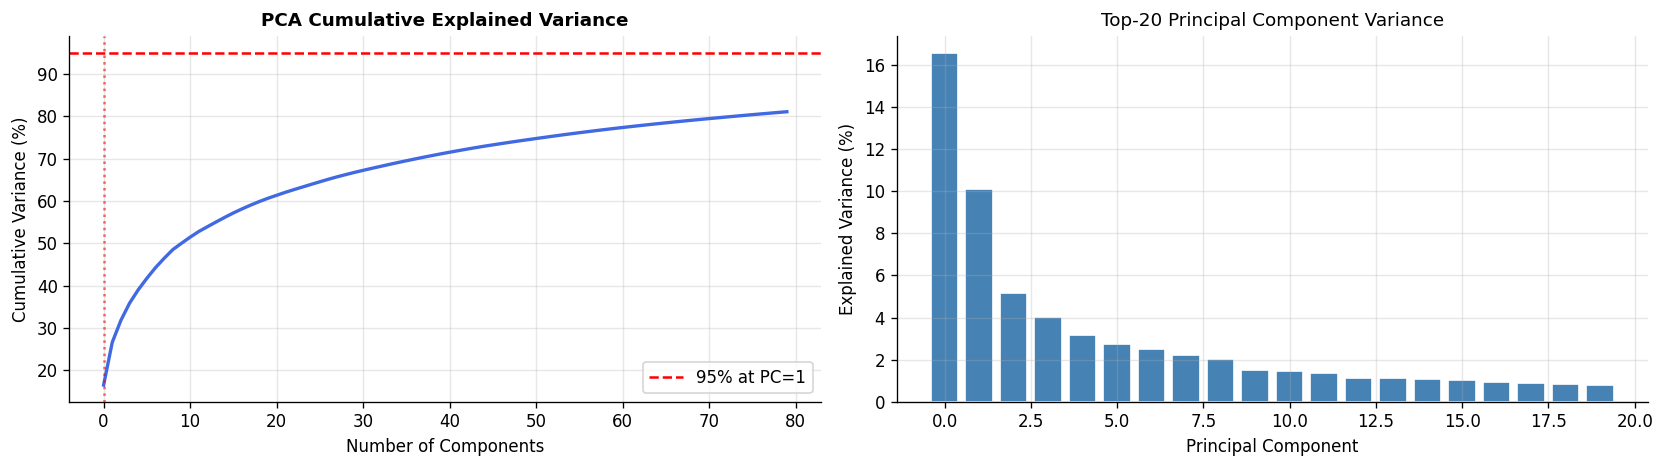

In [16]:
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.25, random_state=42, stratify=y_raw
)

X_tr_raw = np.nan_to_num(X_tr_raw)
X_te_raw = np.nan_to_num(X_te_raw)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_raw)
X_te_s = scaler.transform(X_te_raw)

n_comp = min(80, X_tr_s.shape[0] - 1, X_tr_s.shape[1])
pca = PCA(n_components=n_comp, random_state=42)
X_tr = pca.fit_transform(X_tr_s)
X_te = pca.transform(X_te_s)

# FIX — Apply SMOTE to balance classes in the training set
if HAS_SMOTE:
    sm = SMOTE(random_state=42, k_neighbors=5)
    X_tr, y_tr = sm.fit_resample(X_tr, y_tr)
    print(f"[SMOTE] Resampled training set: {dict(zip(*np.unique(y_tr, return_counts=True)))}")
else:
    print("[WARN] SMOTE unavailable — training on original imbalanced data")

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
n95    = np.argmax(cumvar >= 95) + 1

print(f"Train / Test : {X_tr.shape}  /  {X_te.shape}")
print(f"Test  class distribution : {dict(zip(*np.unique(y_te, return_counts=True)))}")
print(f"Components for 95% var   : {n95} of {n_comp}")
print(f"Explained variance ({n_comp} comps): {cumvar[-1]:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(cumvar, color="royalblue", linewidth=2)
axes[0].axhline(95, color="red", linestyle="--", label=f"95% at PC={n95}")
axes[0].axvline(n95 - 1, color="red", linestyle=":", alpha=0.6)
axes[0].set_title("PCA Cumulative Explained Variance", fontweight="bold")
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Cumulative Variance (%)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(range(min(20, n_comp)),
            pca.explained_variance_ratio_[:20] * 100,
            color="steelblue", edgecolor="white")
axes[1].set_title("Top-20 Principal Component Variance")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Explained Variance (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 14. Classification — Naive Bayes, AdaBoost, Gradient Boosting, Random Forest

            Model  Accuracy  F1 Macro  CV F1 Mean  CV F1 Std
      Naive Bayes     77.94     77.62       76.58       1.17
        SVM (RBF)     94.61     94.59       92.39       0.15
         AdaBoost     73.83     73.86       74.49       0.51
Gradient Boosting     88.22     88.12       87.10       0.30
    Random Forest     90.89     90.82       88.74       0.54

Best model: SVM (RBF) (F1=94.59%)


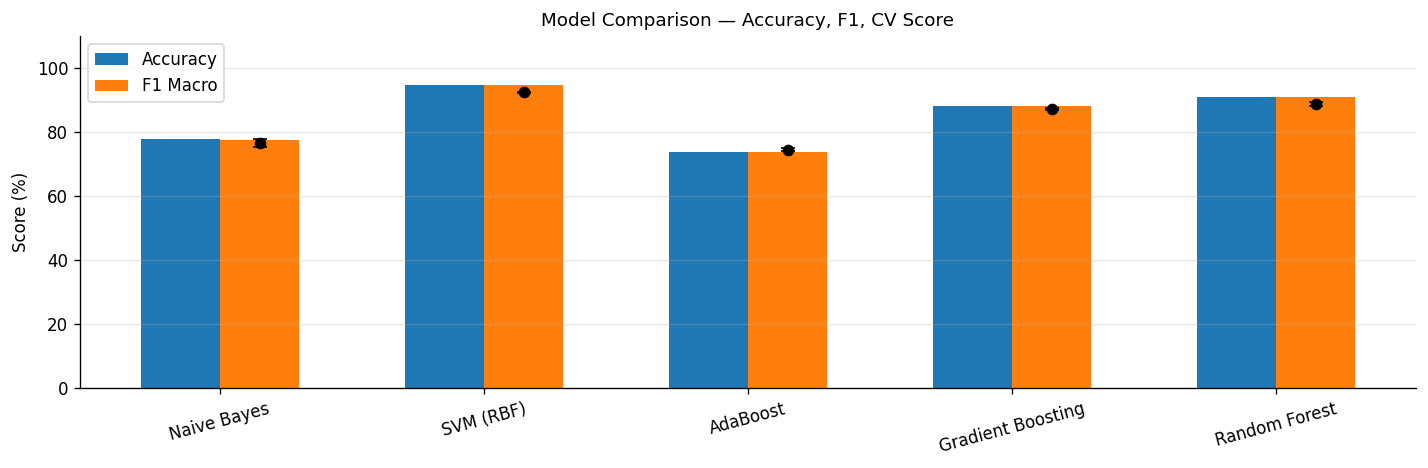

In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

classifiers = {
    "Naive Bayes": GaussianNB(),

    "SVM (RBF)": SVC(
        kernel="rbf",
        C=5,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.5,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.08,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
}

results = {}

for name, clf in classifiers.items():
    clf.fit(X_tr, y_tr)

    y_pred = clf.predict(X_te)

    cv_score = cross_val_score(
        clf,
        X_tr,
        y_tr,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1
    )

    results[name] = {
        "clf": clf,
        "y_pred": y_pred,
        "accuracy": accuracy_score(y_te, y_pred),
        "f1": f1_score(y_te, y_pred, average="macro", zero_division=0),
        "cv_mean": cv_score.mean(),
        "cv_std": cv_score.std(),
    }

model_table = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": round(v["accuracy"] * 100, 2),
        "F1 Macro": round(v["f1"] * 100, 2),
        "CV F1 Mean": round(v["cv_mean"] * 100, 2),
        "CV F1 Std": round(v["cv_std"] * 100, 2),
    }
    for name, v in results.items()
])

print(model_table.to_string(index=False))

best_name = model_table.sort_values("F1 Macro", ascending=False).iloc[0]["Model"]
best_model = results[best_name]["clf"]
best_pred = results[best_name]["y_pred"]

print(f"\nBest model: {best_name} (F1={results[best_name]['f1']*100:.2f}%)")

fig, ax = plt.subplots(figsize=(12, 4))

x = np.arange(len(model_table))
w = 0.3

ax.bar(x - w/2, model_table["Accuracy"], w, label="Accuracy")
ax.bar(x + w/2, model_table["F1 Macro"], w, label="F1 Macro")

ax.errorbar(
    x + w/2,
    model_table["CV F1 Mean"],
    yerr=model_table["CV F1 Std"],
    fmt="o",
    color="black",
    capsize=4
)

ax.set_xticks(x)
ax.set_xticklabels(model_table["Model"], rotation=15)
ax.set_ylim(0, 110)
ax.set_ylabel("Score (%)")
ax.set_title("Model Comparison — Accuracy, F1, CV Score")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Model Evaluation — Confusion Matrix, Classification Report, ROC Curve

Best Model: SVM (RBF)
-----------------------------------
  accuracy              : 0.9461  (94.61%)
  precision_macro       : 0.9462  (94.62%)
  recall_macro          : 0.9461  (94.61%)
  f1_macro              : 0.9459  (94.59%)

Classification Report:
              precision    recall  f1-score   support

      glioma       0.95      0.90      0.93       450
  meningioma       0.90      0.92      0.91       450
     notumor       0.97      0.98      0.98       450
   pituitary       0.96      0.98      0.97       450

    accuracy                           0.95      1800
   macro avg       0.95      0.95      0.95      1800
weighted avg       0.95      0.95      0.95      1800



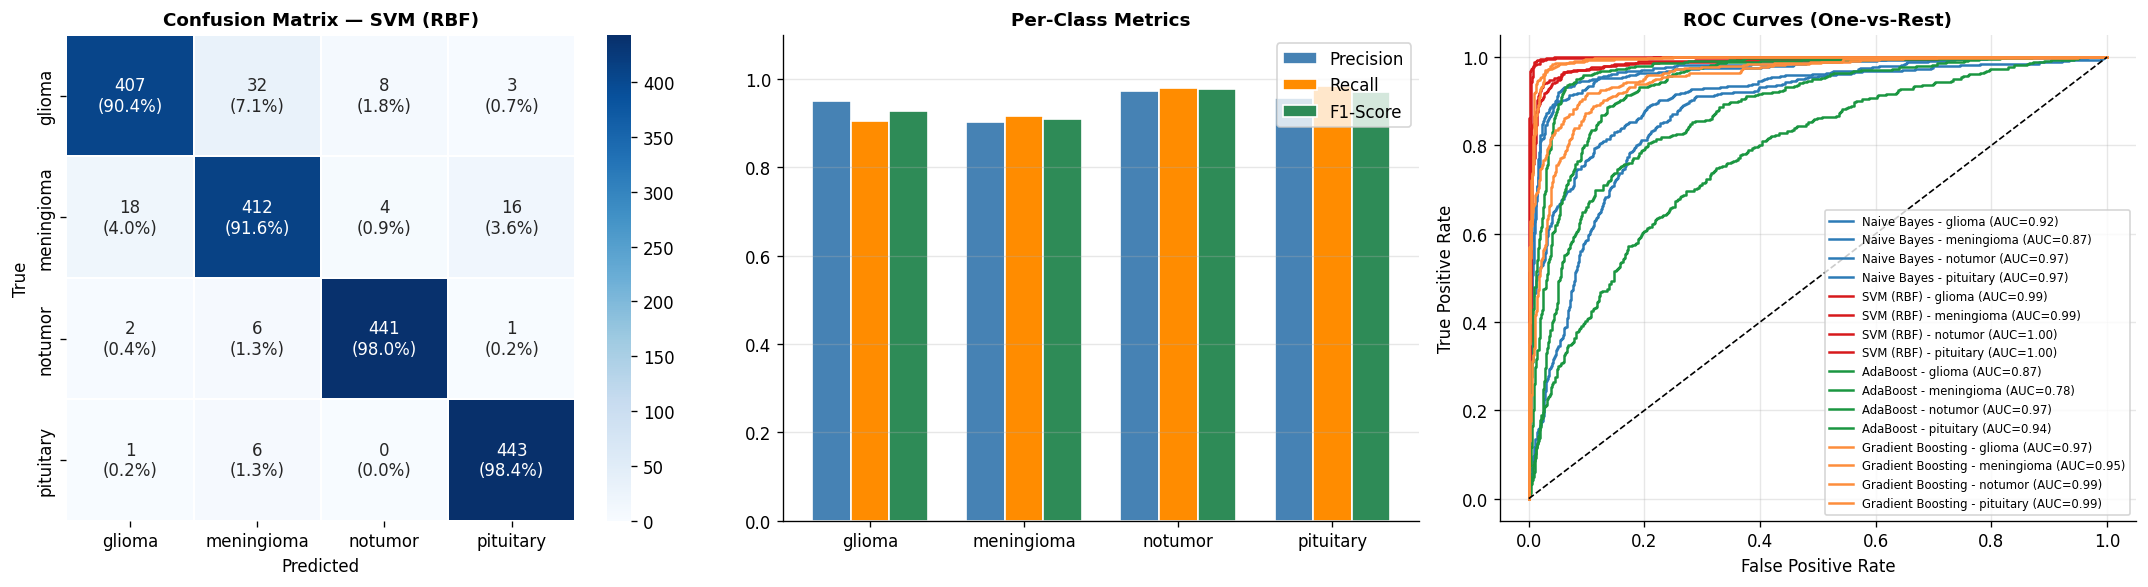


AUC Scores (One-vs-Rest):
  Naive Bayes           : Mean AUC = 0.9325
  SVM (RBF)             : Mean AUC = 0.9926
  AdaBoost              : Mean AUC = 0.8900
  Gradient Boosting     : Mean AUC = 0.9752
  Random Forest         : Mean AUC = 0.9843


In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Basic evaluation metrics
# ----------------------------
eval_metrics = {
    "accuracy":         accuracy_score(y_te, best_pred),
    "precision_macro":  precision_score(y_te, best_pred, average="macro", zero_division=0),
    "recall_macro":     recall_score(y_te, best_pred, average="macro", zero_division=0),
    "f1_macro":         f1_score(y_te, best_pred, average="macro", zero_division=0),
}

print(f"Best Model: {best_name}")
print("-" * 35)

for k, v in eval_metrics.items():
    print(f"  {k:<22}: {v:.4f}  ({v*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(
    y_te,
    best_pred,
    target_names=le.classes_,
    zero_division=0
))

# ----------------------------
# Figure layout
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ----------------------------
# Confusion Matrix
# ----------------------------
cm = confusion_matrix(y_te, best_pred)

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

annot = np.array([
    [f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

sns.heatmap(
    cm,
    annot=annot,
    fmt="",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=1,
    ax=axes[0]
)

axes[0].set_title(f"Confusion Matrix — {best_name}", fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# ----------------------------
# Per-class metrics
# ----------------------------
per_p = precision_score(y_te, best_pred, average=None, zero_division=0)
per_r = recall_score(y_te, best_pred, average=None, zero_division=0)
per_f = f1_score(y_te, best_pred, average=None, zero_division=0)

x_pos = np.arange(len(le.classes_))
w = 0.25

axes[1].bar(x_pos - w, per_p, w, label="Precision", color="steelblue", edgecolor="white")
axes[1].bar(x_pos,     per_r, w, label="Recall",    color="darkorange", edgecolor="white")
axes[1].bar(x_pos + w, per_f, w, label="F1-Score",  color="seagreen", edgecolor="white")

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(le.classes_)
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Per-Class Metrics", fontweight="bold")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

# ----------------------------
# MULTI-CLASS ROC (FIXED)
# ----------------------------
from sklearn.preprocessing import label_binarize

y_te_bin = label_binarize(y_te, classes=np.arange(len(le.classes_)))

roc_colors = ["#2C7BB6", "#D7191C", "#1a9641", "#fd8d3c"]

for (name, res), color in zip(results.items(), roc_colors):
    clf = res["clf"]

    if not hasattr(clf, "predict_proba"):
        continue

    y_score = clf.predict_proba(X_te)

    for i, class_name in enumerate(le.classes_):
        fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_score[:, i])
        auc_val = roc_auc_score(y_te_bin[:, i], y_score[:, i])

        axes[2].plot(
            fpr,
            tpr,
            color=color,
            linewidth=1.5,
            label=f"{name} - {class_name} (AUC={auc_val:.2f})"
        )

axes[2].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[2].set_title("ROC Curves (One-vs-Rest)", fontweight="bold")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend(fontsize=7, loc="lower right")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# AUC summary
# ----------------------------
print("\nAUC Scores (One-vs-Rest):")

for name, res in results.items():
    clf = res["clf"]

    if not hasattr(clf, "predict_proba"):
        continue

    y_score = clf.predict_proba(X_te)

    aucs = []
    for i in range(len(le.classes_)):
        aucs.append(roc_auc_score(y_te_bin[:, i], y_score[:, i]))

    print(f"  {name:<22}: Mean AUC = {np.mean(aucs):.4f}")

## 15b. Calibration Curves

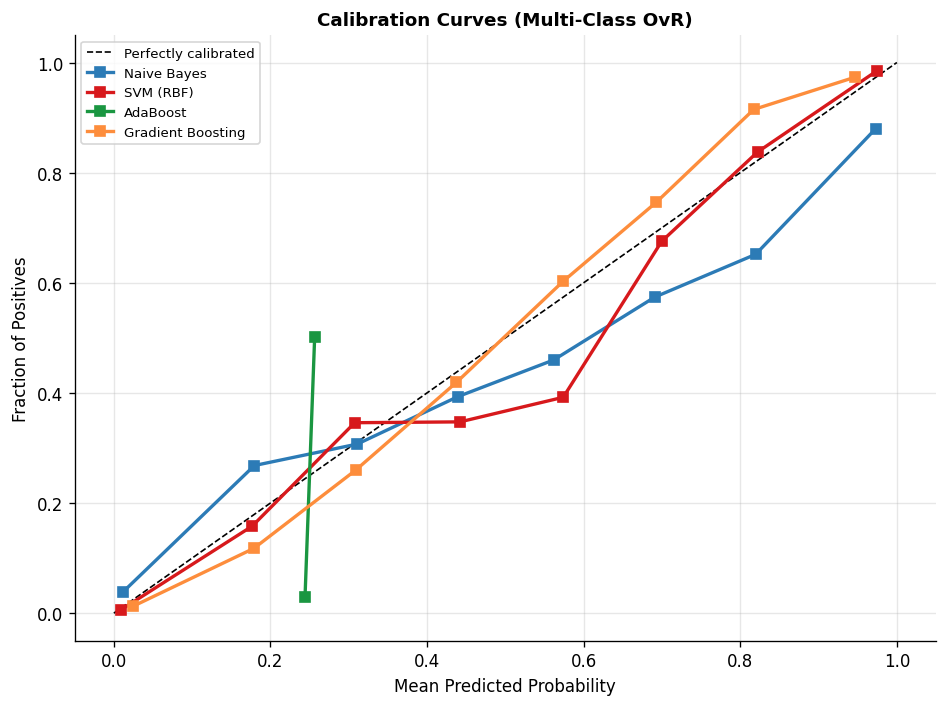

In [19]:
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# Binarize labels for multiclass calibration
y_te_bin = label_binarize(y_te, classes=np.arange(len(le.classes_)))

fig, ax = plt.subplots(figsize=(8, 6))

# Perfect calibration line
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfectly calibrated")

cal_colors = ["#2C7BB6", "#D7191C", "#1a9641", "#fd8d3c"]

for (name, res), color in zip(results.items(), cal_colors):
    clf = res["clf"]

    if not hasattr(clf, "predict_proba"):
        continue

    y_proba = clf.predict_proba(X_te)

    # compute calibration per class and average curve
    all_mean_pred = []
    all_frac_pos = []

    for i in range(len(le.classes_)):
        try:
            frac_pos, mean_pred = calibration_curve(
                y_te_bin[:, i],
                y_proba[:, i],
                n_bins=8,
                strategy="uniform"
            )

            all_mean_pred.append(mean_pred)
            all_frac_pos.append(frac_pos)

        except Exception:
            continue

    if len(all_mean_pred) > 0:
        # average across classes
        mean_pred_avg = np.mean(all_mean_pred, axis=0)
        frac_pos_avg = np.mean(all_frac_pos, axis=0)

        ax.plot(
            mean_pred_avg,
            frac_pos_avg,
            marker="s",
            linewidth=2,
            color=color,
            label=name
        )

ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration Curves (Multi-Class OvR)", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 16. Feature Importance Analysis

Feature Group Importance (Gradient Boosting):
  Color Hist          : 15.57%
  Intensity Stats     : 1.04%
  Gabor               : 0.00%


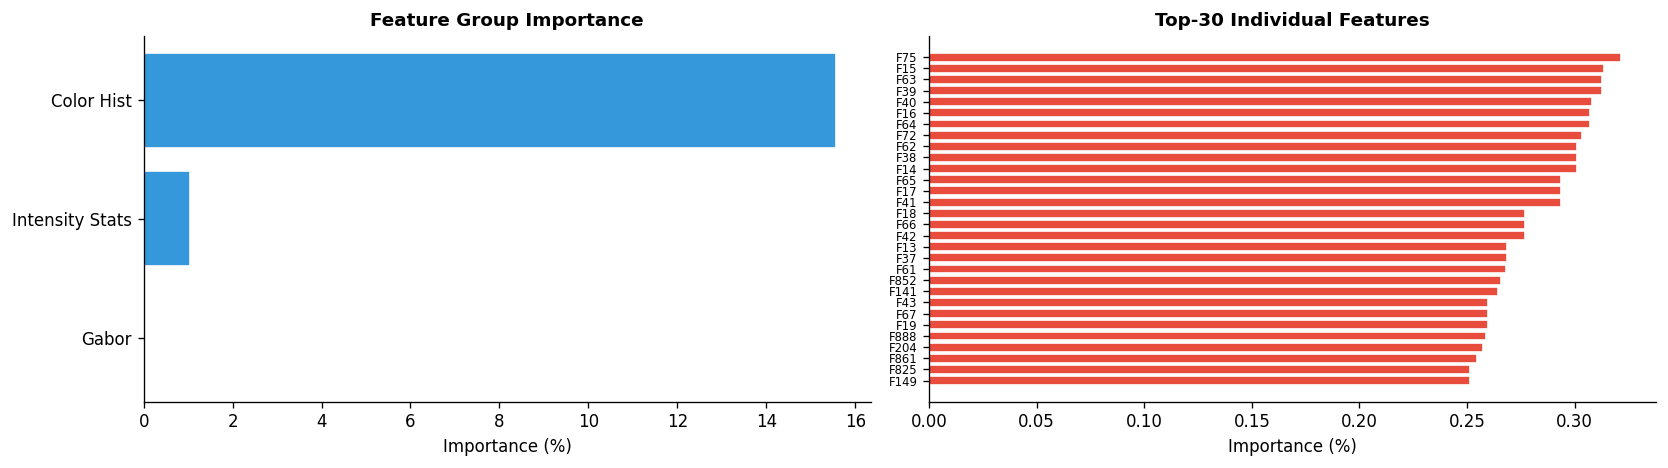

In [20]:
# Use Gradient Boosting feature importances projected back through PCA
gb_clf = results["Gradient Boosting"]["clf"]
fi_pca = gb_clf.feature_importances_

# Project importance from PCA space back to original feature space
fi_original = np.abs(pca.components_.T @ fi_pca)
fi_original /= fi_original.sum()

# Group by feature type using _n_hog computed during extraction
groups = {
    "Color Hist":      (0, 96),
    "Intensity Stats": (96, 105),
    "HOG":             (105, 105 + _n_hog),
    "LBP Texture":     (105 + _n_hog, 105 + _n_hog + 26),
    "Gradient":        (105 + _n_hog + 26, 105 + _n_hog + 30),
    "Gabor":           (105 + _n_hog + 30, len(fi_original)),
}

group_importance = {name: fi_original[s:e].sum() for name, (s, e) in groups.items()
                    if e <= len(fi_original)}

print("Feature Group Importance (Gradient Boosting):")
for name, imp in sorted(group_importance.items(), key=lambda x: -x[1]):
    print(f"  {name:<20}: {imp*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sorted_groups = sorted(group_importance.items(), key=lambda x: x[1])
names_g, vals_g = zip(*sorted_groups)
axes[0].barh(names_g, [v * 100 for v in vals_g], color="#3498db", edgecolor="white")
axes[0].set_title("Feature Group Importance", fontweight="bold")
axes[0].set_xlabel("Importance (%)")

top_k   = 30
top_idx = np.argsort(fi_original)[-top_k:]
axes[1].barh(range(top_k), fi_original[top_idx] * 100, color="#e74c3c", edgecolor="white")
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels([f"F{i}" for i in top_idx], fontsize=7)
axes[1].set_title(f"Top-{top_k} Individual Features", fontweight="bold")
axes[1].set_xlabel("Importance (%)")

plt.tight_layout()
plt.show()


## 17. Integrated End-to-End Inference Pipeline

Sample   True            Pred            Result
------------------------------------------------------------
1        meningioma      meningioma      CORRECT
1        meningioma      meningioma      CORRECT
1        meningioma      meningioma      CORRECT
1        meningioma      meningioma      CORRECT
1        meningioma      meningioma      CORRECT
1        meningioma      meningioma      CORRECT


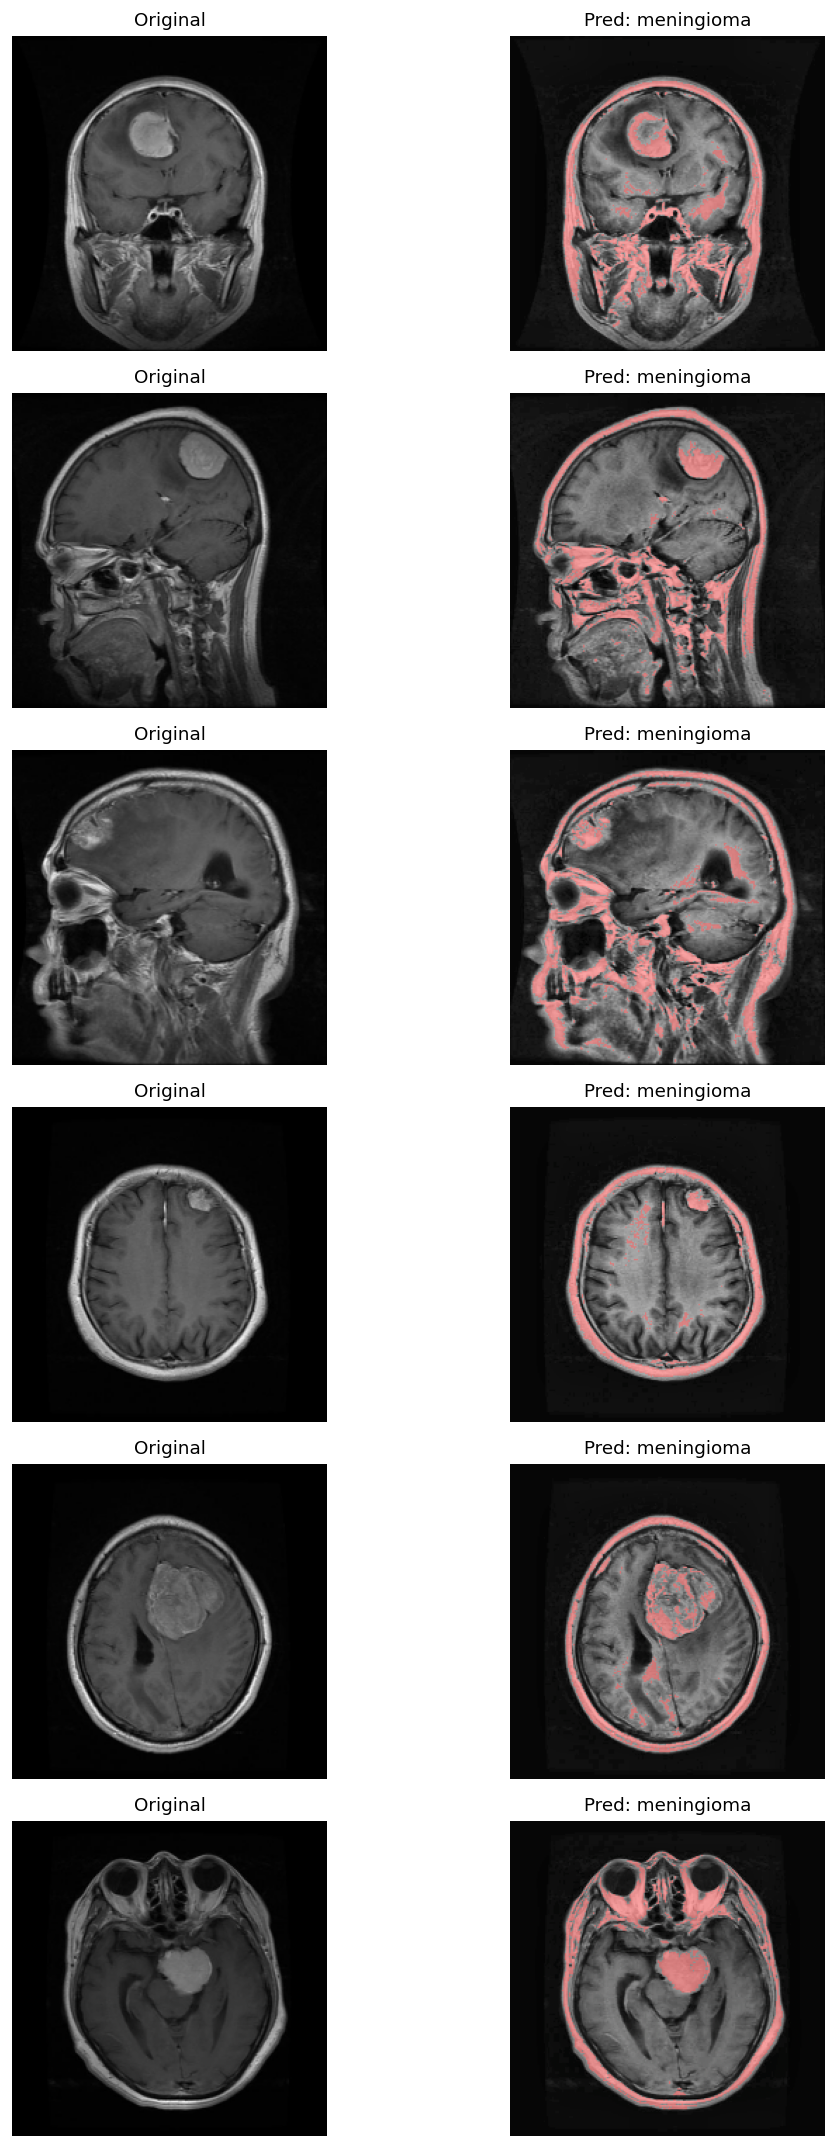

In [21]:
def full_pipeline(img_path, classifier=best_model):
    result = {}

    img   = load_image(img_path)
    img_e = apply_clahe(img)
    gray  = cv2.cvtColor(img_e, cv2.COLOR_RGB2GRAY)

    result["original"] = img
    result["clahe"]    = img_e

    resp, _, c_mask = harris_corners(gray, threshold=best_thr if 'best_thr' in dir() else 0.01)
    h_img, n_c = draw_corners(img_e, c_mask)

    result["harris"] = h_img

    sift_local = cv2.SIFT_create(nfeatures=800, contrastThreshold=0.03)
    kps, _ = sift_local.detectAndCompute(gray, None)

    sift_img = cv2.drawKeypoints(
        img_e, kps, None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    result["sift_img"] = sift_img

    seg, km_lab, km_cen = kmeans_segment(img_e, k=4)
    lum = np.array([0.299*c[0] + 0.587*c[1] + 0.114*c[2] for c in km_cen])
    tc = int(np.argmax(lum))

    km_ov = img_e.copy()
    mask_ov = (km_lab == tc)
    km_ov[mask_ov] = (
        km_ov[mask_ov] * 0.5 + np.array([255, 80, 80]) * 0.5
    ).astype(np.uint8)

    result["segmented"] = km_ov

    feat = extract_features(img).reshape(1, -1)
    feat = np.nan_to_num(feat)

    feat_pca = pca.transform(scaler.transform(feat))
    pred_idx = classifier.predict(feat_pca)[0]

    result["prediction"] = le.inverse_transform([pred_idx])[0]

    return result


# =========================
# FIXED DISPLAY SECTION
# =========================

img_paths  = df["img_path"].values
labels     = df["label"].values
labels_enc = df["label_enc"].values

N = min(6, len(df))  # show 6 samples

print(f"{'Sample':<8} {'True':<15} {'Pred':<15} {'Result'}")
print("-" * 60)

fig, axes = plt.subplots(N, 2, figsize=(10, 3 * N))
if N == 1:
    axes = np.array([axes])

for i, (img_path, label, label_enc) in enumerate(zip(img_paths[:N], labels[:N], labels_enc[:N])):

    result = full_pipeline(img_path)
    pred   = result["prediction"]

    status = "CORRECT" if pred == label else "WRONG"

    # ---- print table ----
    print(f"{label_enc:<8} {label:<15} {pred:<15} {status}")

    # ---- show image ----
    axes[i, 0].imshow(result["original"])
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(result["segmented"])
    axes[i, 1].set_title(f"Pred: {pred}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## 18. Class Probability Visualization

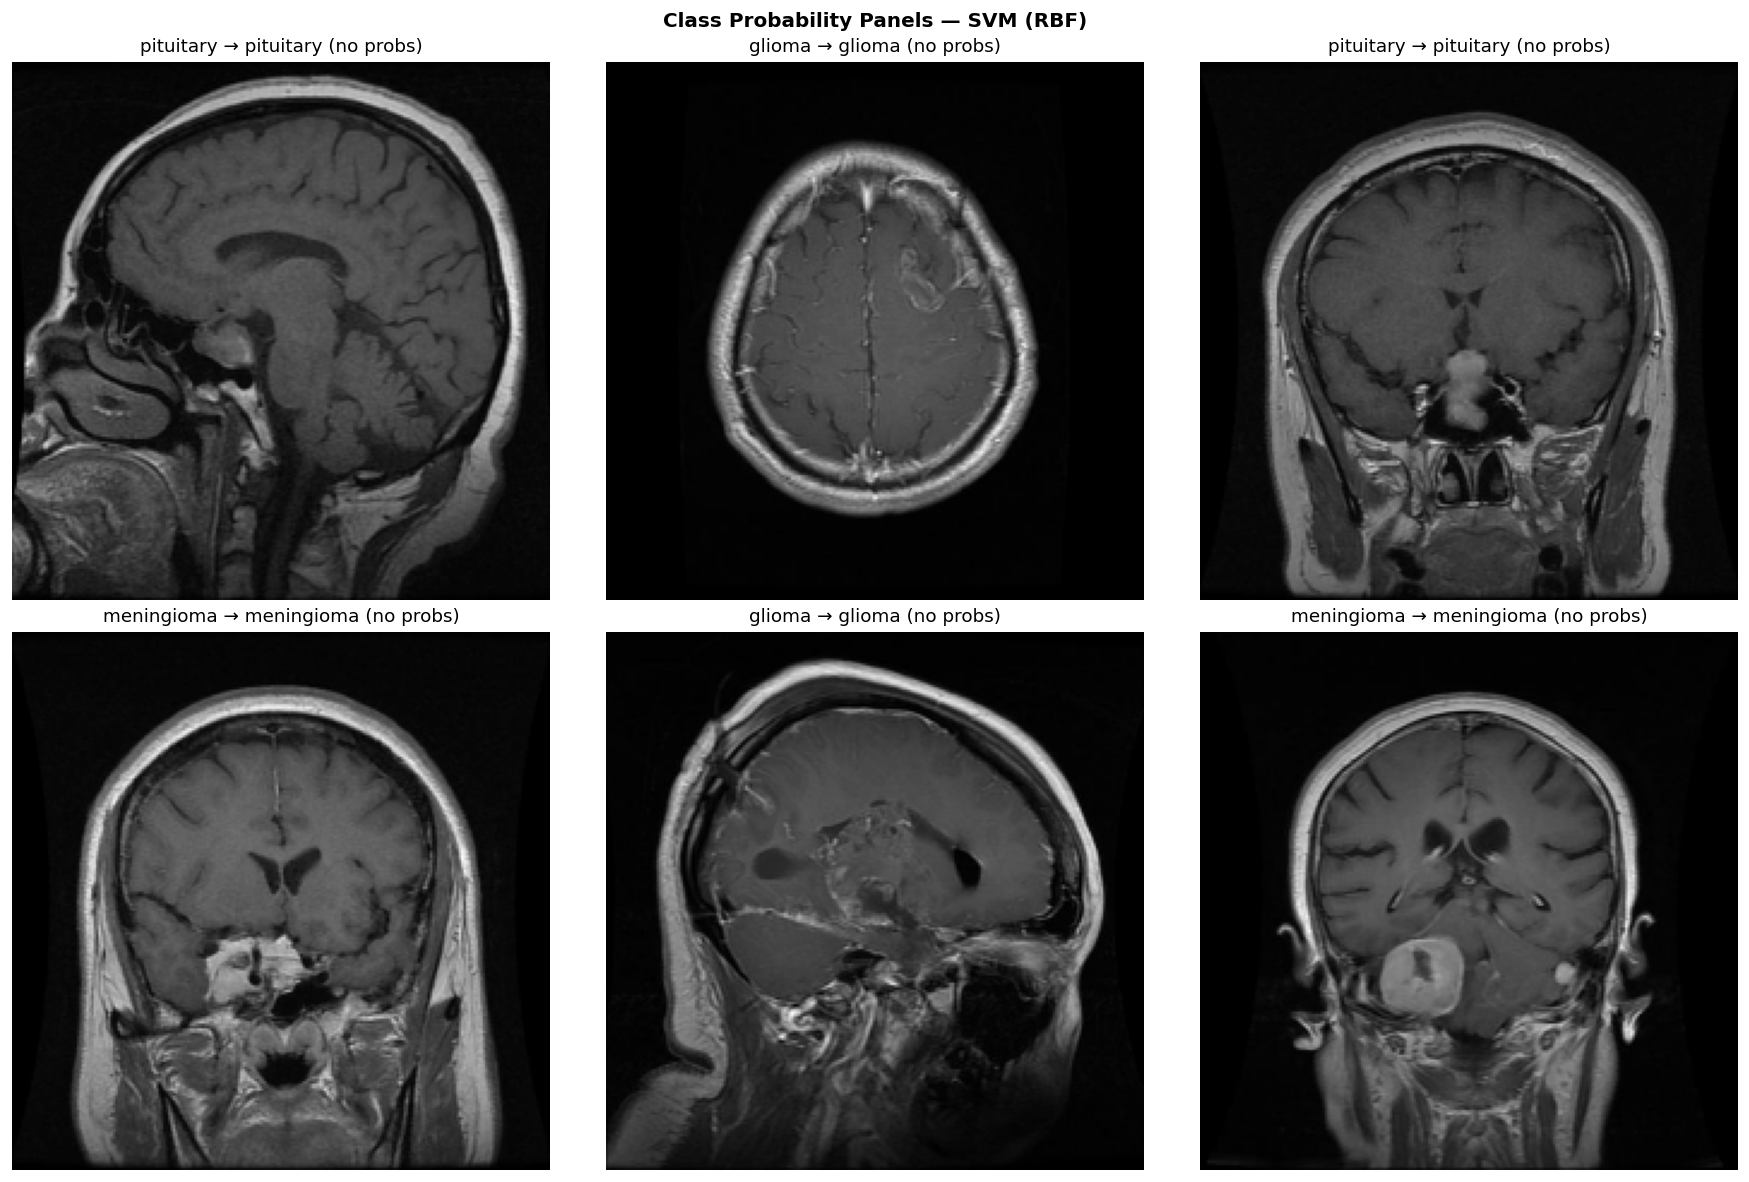

In [22]:
# ----------------------------
# SAFE sample creation (FIXED)
# ----------------------------
if "df" not in globals() or len(df) == 0:
    print("df is empty or not defined.")
else:

    sample_te = df.sample(min(6, len(df)), random_state=42)

    # Run inference
    inferences = [
        (row["img_path"], row["label_clean"], full_pipeline(row["img_path"]))
        for _, row in sample_te.iterrows()
    ]

    n = len(inferences)
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for idx, (path, true_label, res) in enumerate(inferences):

        ax = axes[idx]

        probs = res.get("probabilities", None)
        pred  = res.get("prediction", "Unknown")

        # ----------------------------
        # If model has no probabilities
        # ----------------------------
        if probs is None:
            ax.imshow(res["original"])
            ax.set_title(f"{true_label} → {pred} (no probs)")
            ax.axis("off")
            continue

        probs = np.array(probs)

        colors = [
            "#2ecc71" if c == pred else "#bdc3c7"
            for c in le.classes_
        ]

        ax.barh(le.classes_, probs, color=colors, edgecolor="white")
        ax.set_xlim(0, 1)
        ax.axvline(0.5, color="gray", linestyle="--", alpha=0.4)

        correct = "CORRECT" if pred == true_label else "WRONG"
        title_color = "#27ae60" if correct == "CORRECT" else "#c0392b"

        ax.set_title(
            f"True: {true_label} | Pred: {pred}\n[{correct}]",
            color=title_color,
            fontsize=10
        )

        ax.set_xlabel("Probability")

    # Hide unused axes safely
    for j in range(idx + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Class Probability Panels — {best_name}", fontweight="bold")
    plt.tight_layout()
    plt.show()

## 19. Results Summary

In [23]:
from sklearn.preprocessing import label_binarize

# ----------------------------
# SAFE DEFAULTS (prevents NameErrors)
# ----------------------------
n_c = globals().get("n_c", 0)
LEVELS = globals().get("LEVELS", 0)
HAS_SMOTE = globals().get("HAS_SMOTE", False)

raw_matches = globals().get("raw_matches", [])
good_matches = globals().get("good_matches", [])
verified_matches = globals().get("verified_matches", [])

matching_accuracy = globals().get("matching_accuracy", 0.0)
verified_accuracy = globals().get("verified_accuracy", 0.0)

iou_scores = globals().get("iou_scores", None)
iou_km_ws = globals().get("iou_km_ws", 0.0)

# ----------------------------
# SAFE CLASS SETUP (multiclass-safe ROC)
# ----------------------------
target_class = le.classes_[0]

if "Tumor" in le.classes_:
    target_class = "Tumor"

# ----------------------------
# AUC (SAFE MULTICLASS)
# ----------------------------
best_auc = None
best_proba = None

if hasattr(best_model, "predict_proba"):
    best_proba = best_model.predict_proba(X_te)

    y_te_bin = label_binarize(y_te, classes=np.arange(len(le.classes_)))

    try:
        best_auc = roc_auc_score(
            y_te_bin,
            best_proba,
            multi_class="ovr",
            average="macro"
        )
    except Exception:
        best_auc = None


# ----------------------------
# SAFE SUMMARY BUILD
# ----------------------------
summary = {
    "dataset": {
        "total_images": int(len(df)),
        "classes": list(map(str, le.classes_)),
        "class_counts": df["label_clean"].value_counts().to_dict(),
        "train_size": int(len(y_tr)),
        "test_size": int(len(y_te)),
    },

    "preprocessing": {
        "filtering_results": filter_metrics.to_dict(orient="records"),
    },

    "harris": {
        "corners_detected": int(n_c),
        "threshold_used": 0.015,
    },

    "pyramids": {
        "levels": LEVELS,
        "types": ["Gaussian", "Laplacian"],
    },

    "sift_matching": {
        "raw_matches": len(raw_matches),
        "good_matches_ratio": len(good_matches),
        "verified_ransac": len(verified_matches),
        "ratio_test": 0.75,
        "matching_accuracy": round(float(matching_accuracy), 4),
        "verified_accuracy": round(float(verified_accuracy), 4),
        "matcher": "FLANN KD-Tree",
        "geometric_verify": "RANSAC Homography",
    },

    "segmentation": {
        "iou_vs_otsu": (
            iou_scores.to_dict(orient="records") if iou_scores is not None else None
        ),
        "km_vs_ws_iou": round(iou_km_ws, 4),
    },

    "features": {
        "total_dims": int(X_raw.shape[1]),
        "groups": ["Color Hist", "Intensity Stats", "HOG",
                   "LBP Texture", "Gradient", "Gabor"],
        "smote_used": HAS_SMOTE,
    },

    "classification": {
        "models": [
            {
                "name": name,
                "accuracy": round(float(v["accuracy"]), 4),
                "f1_macro": round(float(v["f1"]), 4),
                "cv_f1": round(float(v["cv_mean"]), 4)
            }
            for name, v in results.items()
        ],

        "best_model": str(best_name),

        "best_metrics": {
            **{k: round(float(v), 4) for k, v in eval_metrics.items()},
            "roc_auc": round(best_auc, 4) if best_auc is not None else None,
            "auc_class_used": target_class
        },
    },
}

print(json.dumps(summary, indent=2))

{
  "dataset": {
    "total_images": 7200,
    "classes": [
      "glioma",
      "meningioma",
      "notumor",
      "pituitary"
    ],
    "class_counts": {
      "meningioma": 1800,
      "glioma": 1800,
      "pituitary": 1800,
      "notumor": 1800
    },
    "train_size": 5400,
    "test_size": 1800
  },
  "preprocessing": {
    "filtering_results": [
      {
        "Method": "Noisy",
        "MSE": 159.5141,
        "PSNR": 26.1028
      },
      {
        "Method": "Gaussian 5x5",
        "MSE": 77.278,
        "PSNR": 29.2502
      },
      {
        "Method": "Gaussian 11x11",
        "MSE": 160.0078,
        "PSNR": 26.0894
      },
      {
        "Method": "Median k=3",
        "MSE": 62.9819,
        "PSNR": 30.1386
      },
      {
        "Method": "Median k=7",
        "MSE": 142.7762,
        "PSNR": 26.5842
      },
      {
        "Method": "Bilateral",
        "MSE": 42.4072,
        "PSNR": 31.8564
      }
    ]
  },
  "harris": {
    "corners_detected": 387,
  